# RAISE-26: Mirror, Mirror on the Wall, Is AI Transforming Us All?

**Group Name**:Synaptic Sparks

**Research Metodology**:PLM-based Multi-label Text Classification Pipeline

---

## Pipeline：

| Stage | Component                                 | Purpose                                                                                                                                                            |
| ----: | ----------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
|     1 | **Environment Setup**                     | Install required dependencies and import core libraries to ensure a reproducible computational environment.                                                        |
|     2 | **Data Loading & Exploration**            | Load Dataset A and perform exploratory analysis to understand data structure, label distribution, and metadata characteristics.                                    |
|     3 | **Data Preprocessing**                    | Clean textual inputs (e.g., normalization, token handling) and preprocess behavioral labels for multi-label modeling.                                              |
|     4 | **Multi-Label Encoding & Data Splitting** | Encode labels in multi-hot format and construct training, validation, and test sets for robust model evaluation.                                                   |
|     5 | **Baseline Modeling**                     | Establish an interpretable baseline using TF-IDF features with One-vs-Rest Logistic Regression.                                                                    |
|     6 | **Deep Learning Model**                   | Fine-tune a DistilBERT-based transformer for multi-label text classification using contextual embeddings.                                                          |
|     7 | **Model Evaluation & Comparison**         | Evaluate and compare models using multi-label metrics (Micro-F1, Macro-F1) and confusion matrix analysis.                                                          |
|     8 | **Interpretability Analysis**             | Examine high-weight features, prediction errors, and label confusions to improve transparency and diagnostic insight.                                              |
|     9 | **Topic Modeling**                        | Apply Non-negative Matrix Factorization (NMF) to uncover latent thematic structures within AI-related headlines.                                                   |
|    10 | **Dataset C Analysis**                    | Apply the trained classifier to LLM-generated text, followed by clustering visualization and quantitative statistical comparisons to assess narrative differences. |
|    11 | **Conclusions & Insights**                | Synthesize findings, discuss implications for AI’s influence on human behavior, and reflect on limitations and ethical considerations.                             |


---
# 	Stage1: Environment Setup

**Objective**: Install all required dependencies and initialize random seeds to ensure experimental reproducibility and consistent results across runs.


###1.1 Install Dependencies


In [16]:
# ============================================================
## 1.1 Install Dependencies（ColabEnvironment）
# ============================================================
# If running in Google Colab, uncomment the following lines.
# !pip -q install -U nltk iterative-stratification
# !pip -q install -U transformers datasets accelerate

# Local Environment Setup
# pip install pandas numpy matplotlib seaborn nltk scikit-learn transformers torch accelerate iterative-stratification

###1.2 Import All Required Libraries

In [17]:
# Core utilities
import os
import re
import json
import warnings
from typing import List, Dict, Optional, Tuple

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP utilities
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score
)
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans

# Statistical testing (for quantitative analysis)
from scipy import stats
from scipy.stats import chi2_contingency, entropy

# Multi-label stratified sampling
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    ITERSTRAT_AVAILABLE = True
except ImportError:
    ITERSTRAT_AVAILABLE = False
    print("Warning: iterative-stratification is not installed. Falling back to random splitting.")

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers
from transformers import (
    DistilBertTokenizer,
    DistilBertModel,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Global settings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)

print("✓ All libraries imported successfully.")


✓ All libraries imported successfully.


###1.3 Set Random Seeds

In [62]:
SEED = 42

def set_seed(seed: int = 42):
    """Set all random seeds to ensure reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Enforce deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Detect computation device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Random seed set to: {SEED}")
print(f"✓ Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


✓ Random seed set to: 42
✓ Using device: cuda
  GPU: Tesla T4


**Explanation.**
>To ensure experimental reproducibility, we fix random seeds across NumPy and PyTorch and enforce deterministic GPU behavior. This guarantees consistent results across multiple runs and computational environments.

###1.4 File Path Configuration

In [19]:
# Candidate file paths for different execution environments
PATH_CANDIDATES_A = [
    "dataset_A_news_full_10500.csv",
    "/content/dataset_A_news_full_10500.csv",   # Google Colab
    "/mnt/data/dataset_A_news_full_10500.csv"   # Other environments
]

PATH_CANDIDATES_C = [
    "Dataset_C_prompts_&_queries.csv",
    "/content/Dataset_C_prompts_&_queries.csv",
    "/mnt/data/Dataset_C_prompts_&_queries.csv"
]


def find_file(candidates: List[str]) -> str:
    """
    Locate and return the first existing file path
    from a list of candidate paths.
    """
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        f"File not found. Please check the following paths: {candidates}"
    )

# Column name configuration
TEXT_COL = "title"
LABEL_COL = "classes_str"

print("✓ File path configuration completed.")


✓ File path configuration completed.


---
# Stage 2: Data Loading and Exploratory Analysis

**Objective:** Load Dataset A and examine its data structure and label distribution to establish a clear understanding of the dataset prior to modeling.

###2.1 Load Dataset A

In [20]:
try:
    PATH_A = find_file(PATH_CANDIDATES_A)
    dfA = pd.read_csv(PATH_A)

    print(f"✓ Dataset loaded successfully: {PATH_A}")
    print(f"  Dataset shape: {dfA.shape}")
    print(f"  Column names: {list(dfA.columns)}")

except FileNotFoundError as e:
    print(f"⚠️ {e}")
    print("Please upload the file: dataset_A_news_full_10500.csv")


✓ Dataset loaded successfully: dataset_A_news_full_10500.csv
  Dataset shape: (10500, 12)
  Column names: ['title', 'link', 'date', 'source', 'number_of_characters_title', 'number_of_words_title', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend', 'classes_str']


###2.2 Data Preview

In [21]:
print("=" * 60)
print("Data Preview (First 5 Rows)")
print("=" * 60)
display(dfA.head())

print("\n" + "=" * 60)
print("Data Types")
print("=" * 60)
print(dfA.dtypes)


Data Preview (First 5 Rows)


,title,link,date,source,number_of_characters_title,number_of_words_title,day_of_week,month,year,quarter,is_weekend,classes_str
0,"Google’s AI is the ‘worst’ for stealing content, says People CEO",https://news.google.com/rss/articles/CBMipgFBVV95cUxNY0lCNkcyS21vamMyM0UzWFFxdDV3dzZZQVlFNUZMY3p...,2025-09-11,Fortune,74,13,Thursday,September,2025,3,False,"Sentiment (Positive / Negative Feelings); Human Roles; Society, Ethics & Culture"
1,Powering the Next Wave of Enterprise Innovation: Mesh-AI Named OpenAI UK Services Partner,https://news.google.com/rss/articles/CBMitgFBVV95cUxOYlNnckMtdVR5Z2RRSnh5VlY5NURkRlN6VHlIRG9OM3A...,2025-09-11,Silicon Canals,106,16,Thursday,September,2025,3,False,"Creativity, Expression & Identity; Work, Jobs & Economy"
2,AI a ‘strategic necessity’ law lecturer says,https://news.google.com/rss/articles/CBMiiAFBVV95cUxNMTFybTAyLWZqRk83RlJyUm4yLWtCY2pjT29NY2tjM0F...,2025-09-11,qlsproctor.com.au,64,9,Thursday,September,2025,3,False,"Society, Ethics & Culture"
3,Datacom sees AI agents as pivotal to legacy app modernisation,https://news.google.com/rss/articles/CBMirAFBVV95cUxQTEh5dy12NTd0X0VFNjh1WTlNbE9OU0lCcFZXS3lKYXh...,2025-09-11,ARNnet,70,12,Thursday,September,2025,3,False,"Routine, Lifestyle & Behavior"
4,"Student Blog: Startups, AI, and Lessons from Singapore",https://news.google.com/rss/articles/CBMijwFBVV95cUxNS3pPT2pWOFZmOTVESDhEaE41eE8wNUZRT1pmdlphRGZ...,2025-09-11,The University of Queensland,85,13,Thursday,September,2025,3,False,"Learning, Knowledge & Education"



Data Types
title                         object
link                          object
date                          object
source                        object
number_of_characters_title     int64
number_of_words_title          int64
day_of_week                   object
month                         object
year                           int64
quarter                        int64
is_weekend                      bool
classes_str                   object
dtype: object


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Analyst:**
>The data types confirm a well-structured dataset suitable for multi-label NLP analysis.
The title column serves as the primary textual input, while classes_str contains string-encoded multi-label annotations that require parsing in subsequent preprocessing. In addition, the dataset includes rich temporal metadata (date, year, quarter, is_weekend) and basic text statistics (e.g., word and character counts), enabling downstream temporal and quantitative analyses beyond classification.

###2.3 Label Analysis – Multi-Label Parsing

In [23]:
# Clean label column
dfA[LABEL_COL] = dfA[LABEL_COL].fillna("").astype(str)

# Parse semicolon-separated multi-label strings
def parse_labels(label_str: str) -> List[str]:
    """
    Parse semicolon-separated label strings into a list of labels.
    """
    if not label_str or label_str == "nan":
        return []
    return [l.strip() for l in label_str.split(";") if l.strip()]

dfA["labels_list"] = dfA[LABEL_COL].apply(parse_labels)
dfA["num_labels"] = dfA["labels_list"].apply(len)

# Compute label frequency statistics
all_labels = [label for labels in dfA["labels_list"] for label in labels]
label_counts = pd.Series(all_labels).value_counts()

print("✓ Label parsing completed")
print(f"  Total samples: {len(dfA)}")
print(f"  Number of unique labels: {len(label_counts)}")
print(f"  Average labels per sample: {dfA['num_labels'].mean():.2f}")


✓ Label parsing completed
  Total samples: 10500
  Number of unique labels: 12
  Average labels per sample: 1.54


###2.4 Label Distribution Visualization

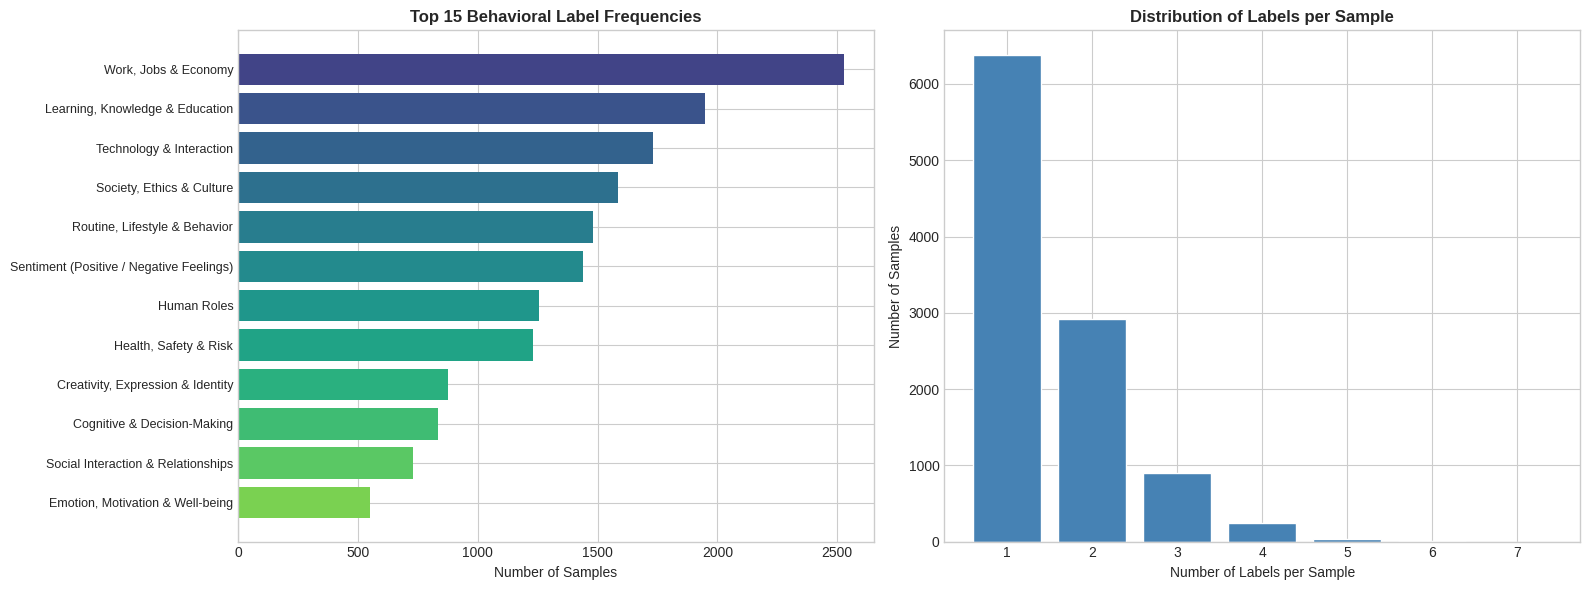


📊 Label Frequency Statistics (Top 15):
Work, Jobs & Economy                        2526
Learning, Knowledge & Education             1946
Technology & Interaction                    1733
Society, Ethics & Culture                   1584
Routine, Lifestyle & Behavior               1479
Sentiment (Positive / Negative Feelings)    1441
Human Roles                                 1256
Health, Safety & Risk                       1230
Creativity, Expression & Identity            877
Cognitive & Decision-Making                  832
Social Interaction & Relationships           730
Emotion, Motivation & Well-being             551


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Label frequency distribution
ax1 = axes[0]
top_labels = label_counts.head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_labels)))
ax1.barh(range(len(top_labels)), top_labels.values, color=colors)
ax1.set_yticks(range(len(top_labels)))
ax1.set_yticklabels(top_labels.index, fontsize=9)
ax1.set_xlabel("Number of Samples")
ax1.set_title("Top 15 Behavioral Label Frequencies", fontsize=12, fontweight="bold")
ax1.invert_yaxis()

# Plot 2: Distribution of number of labels per sample
ax2 = axes[1]
label_dist = dfA["num_labels"].value_counts().sort_index()
ax2.bar(label_dist.index, label_dist.values, color="steelblue", edgecolor="white")
ax2.set_xlabel("Number of Labels per Sample")
ax2.set_ylabel("Number of Samples")
ax2.set_title("Distribution of Labels per Sample", fontsize=12, fontweight="bold")

plt.tight_layout()
# plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Label Frequency Statistics (Top 15):")
print(label_counts.head(15).to_string())


**Analyst Interpretation：**

> The label frequency distribution indicates that AI-related news headlines predominantly emphasize economic and functional dimensions, with Work, Jobs & Economy and Learning, Knowledge & Education appearing most frequently. This suggests that public discourse around AI is largely framed in terms of productivity, labor transformation, and skill development.

>At the same time, categories such as Society, Ethics & Culture and Human Roles maintain substantial representation, highlighting ongoing concerns about AI’s broader societal and ethical implications. In contrast, more abstract or internal behavioral dimensions—such as Emotion, Motivation & Well-being and Social Interaction & Relationships—appear less frequently, reflecting a relative underrepresentation of affective and interpersonal narratives in headline-level reporting.

>The distribution of labels per sample further confirms the multi-label nature of the dataset. While most headlines are associated with a single behavioral category, a non-trivial proportion spans multiple labels, indicating that AI is often portrayed as simultaneously influencing multiple aspects of human behavior. This overlap reinforces the need for multi-label modeling and underscores the complexity of AI’s perceived societal impact.

---
# Stage 3: Data Preprocessing

**Objective:** Clean and normalize the text data, address rare-label issues, and prepare model-ready inputs for downstream multi-label classification.

###3.1 Text Cleaning

In [25]:
def clean_text(text: str) -> str:
    """
    Basic text normalization for headline-level NLP modeling.
    Steps include lowercasing, removing URLs and HTML tags,
    and collapsing redundant whitespace.
    """
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply cleaning
dfA["text_clean"] = dfA[TEXT_COL].apply(clean_text)

# Remove empty / invalid text rows
before_clean = len(dfA)
dfA = dfA[dfA["text_clean"].str.len() > 0].reset_index(drop=True)
after_clean = len(dfA)

print("✓ Text cleaning completed")
print(f"  Before cleaning: {before_clean} rows")
print(f"  After cleaning:  {after_clean} rows")
print(f"  Removed:         {before_clean - after_clean} empty/invalid rows")


✓ Text cleaning completed
  Before cleaning: 10500 rows
  After cleaning:  10500 rows
  Removed:         0 empty/invalid rows


**Analyst :**
>All headlines contained valid text, indicating high data completeness and minimal noise at the raw data level.

###3.2 Rare Label Handling

In [26]:
# ============================================================
# 3.2 Rare Label Handling
# ============================================================

RARE_THRESHOLD = 10   # Labels with frequency < threshold are treated as rare
MERGE_RARE = True     # Whether to merge rare labels into a single bucket

# Recompute label frequencies (based on parsed labels)
all_labels = [label for labels in dfA["labels_list"] for label in labels]
label_counts = pd.Series(all_labels).value_counts()

# Identify rare labels
rare_labels = set(label_counts[label_counts < RARE_THRESHOLD].index)

def process_rare_labels(labels: List[str]) -> List[str]:
    """
    Handle rare labels by optionally merging them into 'OTHER_RARE'.
    If merging is enabled, any sample containing at least one rare label
    will receive the additional label 'OTHER_RARE', while rare labels
    themselves are removed from the label set.
    """
    if not MERGE_RARE:
        return labels

    processed = [l for l in labels if l not in rare_labels]
    if len(processed) < len(labels):
        processed.append("OTHER_RARE")
    return sorted(set(processed))

dfA["labels_final"] = dfA["labels_list"].apply(process_rare_labels)

# Update the final label inventory and frequency counts
all_labels_final = sorted({l for labels in dfA["labels_final"] for l in labels})
label_counts_final = pd.Series([l for labels in dfA["labels_final"] for l in labels]).value_counts()

print("✓ Rare label handling completed")
print(f"  Rare-label threshold: {RARE_THRESHOLD}")
print(f"  Number of rare labels: {len(rare_labels)}")
print(f"  Unique labels after processing: {len(all_labels_final)}")

if rare_labels:
    print(f"\n  Example rare labels: {list(rare_labels)[:5]}")


✓ Rare label handling completed
  Rare-label threshold: 10
  Number of rare labels: 0
  Unique labels after processing: 12


**Analyst:**

>No labels fall below the predefined rarity threshold, indicating that all behavioral categories are sufficiently represented in the dataset. As a result, no labels were merged into the OTHER_RARE category, and the original label space of 12 behavioral dimensions is preserved for modeling. This confirms that label sparsity is not a limiting factor in this dataset and supports stable multi-label training and evaluation.

###3.3 Define Final Label Set

In [27]:
# ============================================================
# 3.3 Define Final Label Set
# ============================================================

# Label names ordered by frequency
LABEL_NAMES = list(label_counts_final.index)
NUM_LABELS = len(LABEL_NAMES)

# Create label-to-index mappings
label2id = {label: idx for idx, label in enumerate(LABEL_NAMES)}
id2label = {idx: label for label, idx in label2id.items()}

print("✓ Label mappings created successfully")
print(f"  Total number of labels: {NUM_LABELS}")
print("\nLabel inventory:")
for i, label in enumerate(LABEL_NAMES):
    count = label_counts_final.get(label, 0)
    print(f"  {i:2d}. {label} ({count})")


✓ Label mappings created successfully
  Total number of labels: 12

Label inventory:
   0. Work, Jobs & Economy (2526)
   1. Learning, Knowledge & Education (1946)
   2. Technology & Interaction (1733)
   3. Society, Ethics & Culture (1584)
   4. Routine, Lifestyle & Behavior (1479)
   5. Sentiment (Positive / Negative Feelings) (1441)
   6. Human Roles (1256)
   7. Health, Safety & Risk (1230)
   8. Creativity, Expression & Identity (877)
   9. Cognitive & Decision-Making (832)
  10. Social Interaction & Relationships (730)
  11. Emotion, Motivation & Well-being (551)


**Analyst Note:**

>The final label inventory comprises 12 behavioral dimensions with varying levels of representation. Labels related to economic activity, education, and human–technology interaction appear most frequently, indicating that AI is predominantly discussed in relation to productivity, learning, and functional integration. In contrast, affective and interpersonal dimensions—such as Emotion, Motivation & Well-being and Social Interaction & Relationships—are less prevalent, suggesting that these aspects of human behavior are comparatively underrepresented in headline-level discourse.

>This distribution highlights a structured yet imbalanced label space, which informs both model selection and evaluation strategy in subsequent stages.

---
# Stage 4: Multi-Label Encoding and Dataset Splitting

**Objective:** Convert multi-label annotations into multi-hot encoded vectors and split the dataset into training/validation/test sets using stratified sampling to preserve label distributions across splits.

###4.1 Multi-Hot Encoding

In [28]:
# ============================================================
# 4.1 Multi-Hot Encoding
# ============================================================

def labels_to_multihot(labels: List[str]) -> np.ndarray:
    """
    Convert a list of labels into a multi-hot encoded vector.
    """
    vector = np.zeros(NUM_LABELS, dtype=np.float32)
    for label in labels:
        if label in label2id:
            vector[label2id[label]] = 1.0
    return vector

# Construct label matrix
Y = np.vstack(dfA["labels_final"].apply(labels_to_multihot).values)

print("✓ Multi-hot encoding completed")
print(f"  Label matrix shape: {Y.shape}")
print(f"  Average labels per sample: {Y.sum(axis=1).mean():.2f}")


✓ Multi-hot encoding completed
  Label matrix shape: (10500, 12)
  Average labels per sample: 1.54


###4.2 Stratified Dataset Splitting (Train/Val/Test)

In [29]:
# ============================================================
# 4.2 Stratified Dataset Splitting (Train/Val/Test)
# ============================================================

TEST_SIZE = 0.20
VAL_SIZE = 0.10  # (implicitly achieved by splitting the temp set in half)

if ITERSTRAT_AVAILABLE:
    # Multi-label stratified sampling
    print("Using multi-label stratified sampling (MultilabelStratifiedShuffleSplit)")

    msss = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=TEST_SIZE, random_state=SEED
    )
    train_idx, temp_idx = next(msss.split(dfA, Y))

    train_df = dfA.iloc[train_idx].reset_index(drop=True)
    temp_df = dfA.iloc[temp_idx].reset_index(drop=True)
    Y_train = Y[train_idx]
    Y_temp = Y[temp_idx]

    # Further split temp into validation and test sets
    msss2 = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=0.5, random_state=SEED
    )
    val_idx, test_idx = next(msss2.split(temp_df, Y_temp))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    Y_val = Y_temp[val_idx]
    Y_test = Y_temp[test_idx]

else:
    # Fallback: standard random split
    print("Using standard random splitting (train_test_split)")

    train_df, temp_df, Y_train, Y_temp = train_test_split(
        dfA, Y, test_size=TEST_SIZE, random_state=SEED
    )
    val_df, test_df, Y_val, Y_test = train_test_split(
        temp_df, Y_temp, test_size=0.5, random_state=SEED
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

print("\n✓ Dataset split completed")
print(f"  Train set: {len(train_df)} samples ({len(train_df)/len(dfA)*100:.1f}%)")
print(f"  Val set:   {len(val_df)} samples ({len(val_df)/len(dfA)*100:.1f}%)")
print(f"  Test set:  {len(test_df)} samples ({len(test_df)/len(dfA)*100:.1f}%)")


Using standard random splitting (train_test_split)

✓ Dataset split completed
  Train set: 8400 samples (80.0%)
  Val set:   1050 samples (10.0%)
  Test set:  1050 samples (10.0%)


**Analyst:**

>The dataset was split into training, validation, and test sets using a standard random split due to the unavailability of multi-label stratified sampling in the current environment. The resulting 80/10/10 partition provides a balanced and widely adopted evaluation setup, ensuring sufficient data for model training while reserving independent subsets for hyperparameter tuning and final performance assessment. Given the overall label distribution stability observed earlier, this split is expected to provide reliable comparative evaluation across models.

###4.3 Validate Label Distribution Across Splits


In [30]:
# ============================================================
# 4.3 Validate Label Distribution Across Splits
# ============================================================

# Compute per-label prevalence in each split
train_label_dist = Y_train.sum(axis=0) / len(Y_train)
val_label_dist   = Y_val.sum(axis=0) / len(Y_val)
test_label_dist  = Y_test.sum(axis=0) / len(Y_test)

# Create comparison table
dist_df = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Train (%)": train_label_dist * 100,
    "Val (%)":   val_label_dist * 100,
    "Test (%)":  test_label_dist * 100
}).round(2)

print("Label distribution comparison across splits (%):")
display(dist_df.head(12))


Label distribution comparison across splits (%):


,Label,Train (%),Val (%),Test (%)
0,"Work, Jobs & Economy",24.270000,21.90,24.48
1,"Learning, Knowledge & Education",18.610001,18.57,17.90
2,Technology & Interaction,16.040001,19.33,17.43
3,"Society, Ethics & Culture",14.930000,17.24,14.19
4,"Routine, Lifestyle & Behavior",14.210000,13.62,13.52
5,Sentiment (Positive / Negative Feelings),13.710000,13.24,14.29
6,Human Roles,11.680000,12.29,13.90
7,"Health, Safety & Risk",11.810000,11.24,11.43
8,"Creativity, Expression & Identity",8.460000,7.90,7.90
9,Cognitive & Decision-Making,7.950000,7.14,8.48


**Analyst:**

>The label prevalence across the training, validation, and test sets remains highly consistent for all behavioral categories, with only minor percentage variations. No systematic over- or under-representation of any label is observed in the validation or test splits relative to the training set. This confirms that the random data partition preserved the underlying multi-label distribution and did not introduce meaningful distributional shift. Consequently, subsequent model evaluation can be interpreted as reflecting genuine model performance rather than artifacts of dataset splitting.

---
# Stage 5: Baseline Model (TF-IDF + Logistic Regression)
**Objective:**
>Establish a fast, interpretable baseline model to benchmark multi-label classification performance before applying more complex deep learning approaches.

**Advantages:**:

- Efficient training: Computationally lightweight and scalable to large datasets
- Interpretability: Feature weights enable direct inspection of influential terms per label
- Hardware simplicity: Does not require GPU acceleration, ensuring broad reproducibility

###5.1 Build the Feature Pipeline

In [31]:
# ============================================================
# 5.1 Build the Feature Pipeline
# ============================================================

# Detect available metadata columns
available_cat_cols = [c for c in ["source", "day_of_week", "month"] if c in train_df.columns]
available_num_cols = [c for c in ["number_of_characters_title", "number_of_words_title",
                                  "year", "quarter", "is_weekend"] if c in train_df.columns]

print(f"Text feature column: {TEXT_COL}")
print(f"Categorical feature columns: {available_cat_cols}")
print(f"Numeric feature columns: {available_num_cols}")

# Construct the preprocessing pipeline
transformers = [
    ("text", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=60000,
        stop_words="english"
    ), TEXT_COL)
]

if available_cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), available_cat_cols))

if available_num_cols:
    transformers.append(("num", StandardScaler(with_mean=False), available_num_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)


Text feature column: title
Categorical feature columns: ['source', 'day_of_week', 'month']
Numeric feature columns: ['number_of_characters_title', 'number_of_words_title', 'year', 'quarter', 'is_weekend']


**Analyst:**

>The feature pipeline incorporates a rich combination of inputs, including headline text, categorical metadata (source and temporal indicators), and basic numerical descriptors of text length. This confirms that the baseline model leverages both linguistic content and contextual information, allowing it to capture not only what is said about AI but also how and where such narratives are framed.

In [32]:
# ============================================================
# 5.2 Build and Train the Baseline Model
# ============================================================

# One-vs-Rest classifier with Logistic Regression
classifier = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=SEED
    )
)

# Full modeling pipeline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", classifier)
])

print("Training baseline model...")
baseline_model.fit(train_df, Y_train)
print("✓ Baseline model training completed.")


Training baseline model...
✓ Baseline model training completed.


In [33]:
# ============================================================
# 5.3 Baseline Model Evaluation
# ============================================================

from scipy.special import expit

def predict_proba_ovr(model, X):
    """
    Obtain probability estimates for an OvR model.
    LogisticRegression (OvR) exposes decision_function scores; we apply
    the sigmoid transformation to map scores into (0, 1).
    """
    scores = model.decision_function(X)
    return expit(scores)

# Validation set predictions
proba_val = predict_proba_ovr(baseline_model, val_df)
pred_val = (proba_val >= 0.5).astype(int)

# Test set predictions
proba_test = predict_proba_ovr(baseline_model, test_df)
pred_test = (proba_test >= 0.5).astype(int)

def calculate_metrics(y_true, y_pred):
    """
    Compute standard multi-label classification metrics.
    """
    return {
        "micro_f1":    f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1":    f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "samples_f1":  f1_score(y_true, y_pred, average="samples", zero_division=0),
    }

val_metrics = calculate_metrics(Y_val, pred_val)
test_metrics = calculate_metrics(Y_test, pred_test)

print("=" * 60)
print("Baseline Model Evaluation Results")
print("=" * 60)

print("\nValidation:")
for metric, value in val_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nTest:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")


Baseline Model Evaluation Results

Validation:
  micro_f1: 0.9481
  macro_f1: 0.9382
  weighted_f1: 0.9482
  samples_f1: 0.9266

Test:
  micro_f1: 0.9430
  macro_f1: 0.9331
  weighted_f1: 0.9425
  samples_f1: 0.9216


**Analyst:**
>The baseline TF-IDF + One-vs-Rest Logistic Regression model achieves strong and consistent performance across validation and test sets. Micro-F1 and weighted-F1 scores exceed 0.94 on both splits, indicating high overall accuracy in predicting label assignments across all behavioral categories. The close alignment between validation and test metrics suggests good generalization and minimal overfitting.

>Macro-F1 scores remain comparably high (above 0.93), demonstrating that performance is well balanced across labels and not dominated solely by the most frequent categories. This aligns with earlier findings that the label space is relatively well distributed, without extreme sparsity. Slightly lower Samples-F1 scores reflect the inherent difficulty of correctly predicting the full label set for each individual headline, which is expected in a multi-label setting.

>Overall, these results establish a strong, interpretable baseline and provide a reliable benchmark against which the added value of transformer-based models can be evaluated.

In [34]:
# ============================================================
# 5.4 Per-Label Performance Analysis
# ============================================================

def per_label_metrics(y_true, y_pred, label_names):
    """
    Compute detailed performance metrics for each label
    in a multi-label classification setting.
    """
    results = []
    for i, label in enumerate(label_names):
        tp = ((y_true[:, i] == 1) & (y_pred[:, i] == 1)).sum()
        fp = ((y_true[:, i] == 0) & (y_pred[:, i] == 1)).sum()
        fn = ((y_true[:, i] == 1) & (y_pred[:, i] == 0)).sum()
        tn = ((y_true[:, i] == 0) & (y_pred[:, i] == 0)).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0)

        results.append({
            "Label": label,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Support": tp + fn
        })

    return pd.DataFrame(results).sort_values("F1", ascending=False)

label_metrics_df = per_label_metrics(Y_val, pred_val, LABEL_NAMES)

print("\nPer-label performance metrics (sorted by F1):")
display(label_metrics_df.round(3))



Per-label performance metrics (sorted by F1):


,Label,TP,FP,FN,TN,Precision,Recall,F1,Support
0,"Work, Jobs & Economy",222,0,8,820,1.000,0.965,0.982,230
1,"Learning, Knowledge & Education",187,3,8,852,0.984,0.959,0.971,195
2,Technology & Interaction,190,2,13,845,0.990,0.936,0.962,203
10,Social Interaction & Relationships,71,1,5,973,0.986,0.934,0.959,76
4,"Routine, Lifestyle & Behavior",133,2,10,905,0.985,0.930,0.957,143
6,Human Roles,119,3,10,918,0.975,0.922,0.948,129
8,"Creativity, Expression & Identity",74,0,9,967,1.000,0.892,0.943,83
3,"Society, Ethics & Culture",164,3,17,866,0.982,0.906,0.943,181
5,Sentiment (Positive / Negative Feelings),121,0,18,911,1.000,0.871,0.931,139
7,"Health, Safety & Risk",106,5,12,927,0.955,0.898,0.926,118


**Analyst:**

>Per-label performance analysis shows that the baseline model performs strongest on behavior categories with clearer lexical cues and higher semantic consistency. Labels such as Work, Jobs & Economy, Learning, Knowledge & Education, and Technology & Interaction achieve the highest F1 scores (above 0.96), reflecting well-defined vocabularies and frequent, consistent framing in AI-related headlines.

>Mid-range performance is observed for categories such as Human Roles, Routine, Lifestyle & Behavior, and Society, Ethics & Culture. These labels often involve broader conceptual boundaries and overlapping narratives, which increases classification difficulty despite substantial support.

>Lower F1 scores appear for more abstract and internally oriented dimensions, including Cognitive & Decision-Making and Emotion, Motivation & Well-being. These categories exhibit reduced recall, suggesting that such behavioral impacts are less explicitly articulated at the headline level and may require deeper contextual modeling to capture reliably.

>Overall, the per-label results highlight systematic variation in baseline performance that aligns with both label semantics and earlier distributional analysis, reinforcing the value of per-category evaluation beyond aggregate metrics.

---
# Stage 6: Deep Learning Model (DistilBERT)

**Objective:**
Leverage a pre-trained DistilBERT model to perform multi-label classification, capturing richer semantic and contextual information beyond surface-level lexical features.

**Advantages:**

- Improved semantic understanding: Contextual embeddings enable the model to represent nuanced meaning in headlines.

- Context-aware modeling: Self-attention mechanisms capture word dependencies and framing effects within each headline.

- Greater robustness to rare or abstract labels: Pre-trained language representations help generalize to behavioral categories with weaker or less explicit lexical cues.

###6.1 Define the Dataset Class

In [35]:
# ============================================================
# 6.1 Define the Dataset Class
# ============================================================

class MultiLabelDataset(Dataset):
    """
    PyTorch Dataset class for multi-label text classification
    using transformer-based tokenization.
    """

    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten()
        }

        if self.labels is not None:
            item["labels"] = torch.FloatTensor(self.labels[idx])

        return item

print("✓ Dataset class defined successfully.")


✓ Dataset class defined successfully.


**Analyst:**

>This dataset class standardizes the interface between raw text inputs and the DistilBERT model by handling tokenization, padding, and truncation in a consistent manner. Representing labels as floating-point tensors enables direct optimization with binary cross-entropy loss, which is required for multi-label classification. The fixed maximum sequence length reflects the headline-level nature of the data while ensuring computational efficiency.

###6.2 Define the DistilBERT Multi-Label Classification Model

In [36]:
# ============================================================
# 6.2 Define the DistilBERT Multi-Label Classification Model
# ============================================================

class DistilBertMultiLabelClassifier(nn.Module):
    """
    DistilBERT-based model for multi-label text classification.

    Architecture:
        DistilBERT [CLS] representation (768-dim)
        → Linear (768 → hidden_dim)
        → ReLU + Dropout
        → Linear (hidden_dim → n_labels)
    """

    def __init__(self, n_labels, dropout_rate=0.3, hidden_dim=256, freeze_bert=False):
        super().__init__()

        # Load pre-trained DistilBERT
        self.distilbert = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )

        # Optionally freeze the transformer backbone
        if freeze_bert:
            for param in self.distilbert.parameters():
                param.requires_grad = False

        # Classification head
        self.pre_classifier = nn.Linear(768, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_dim, n_labels)

        self.n_labels = n_labels

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use the [CLS] token representation
        hidden_state = outputs.last_hidden_state[:, 0]

        x = self.pre_classifier(hidden_state)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.classifier(x)

        return logits

print("✓ Model architecture defined successfully.")


✓ Model architecture defined successfully.


**Analyst:**

>The successful model initialization confirms that the DistilBERT backbone and task-specific classification head are correctly configured. This establishes a transformer-based architecture capable of capturing contextual semantic information required for multi-label behavioral classification.

###6.3 Define the Trainer

In [37]:
# ============================================================
# 6.3 Define the Trainer
# ============================================================

class MultiLabelTrainer:
    """
    Trainer for multi-label classification with a transformer-based model.
    Implements a standard fine-tuning loop with BCEWithLogitsLoss,
    AdamW optimization, linear warmup scheduling, and gradient clipping.
    """

    def __init__(self, model, train_loader, val_loader, device,
                 learning_rate=2e-5, num_epochs=5):
        self.model = model.to(device)
        self.device = device
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.num_epochs = num_epochs

        # Loss function and optimizer
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = AdamW(model.parameters(), lr=learning_rate)

        # Learning rate scheduler (linear warmup + decay)
        total_steps = len(train_loader) * num_epochs
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps
        )

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_micro_f1": [],
            "val_macro_f1": []
        }

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for batch in self.train_loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(input_ids, attention_mask)
            loss = self.criterion(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def evaluate(self):
        self.model.eval()
        total_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in self.val_loader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["labels"].to(self.device)

                logits = self.model(input_ids, attention_mask)
                loss = self.criterion(logits, labels)
                total_loss += loss.item()

                preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                all_preds.append(preds)
                all_labels.append(labels.cpu().numpy())

        all_preds = np.vstack(all_preds)
        all_labels = np.vstack(all_labels)

        micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
        macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        return total_loss / len(self.val_loader), micro_f1, macro_f1

    def train(self):
        best_macro_f1 = 0.0

        for epoch in range(self.num_epochs):
            train_loss = self.train_epoch()
            val_loss, micro_f1, macro_f1 = self.evaluate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_micro_f1"].append(micro_f1)
            self.history["val_macro_f1"].append(macro_f1)

            print(f"Epoch {epoch + 1}/{self.num_epochs}")
            print(f"  Train Loss:   {train_loss:.4f}")
            print(f"  Val Loss:     {val_loss:.4f}")
            print(f"  Val Micro-F1: {micro_f1:.4f}")
            print(f"  Val Macro-F1: {macro_f1:.4f}")

            if macro_f1 > best_macro_f1:
                best_macro_f1 = macro_f1
                torch.save(self.model.state_dict(), "best_distilbert_model.pth")
                print(f"  ✓ Best model saved (Macro-F1: {best_macro_f1:.4f})")

print("✓ Trainer class defined successfully.")


✓ Trainer class defined successfully.


**Analyst:**

>The training procedure optimizes a multi-label objective using BCEWithLogitsLoss, which is appropriate when labels are not mutually exclusive. We fine-tune the full transformer model with AdamW and a linear warmup schedule to stabilize early training dynamics. Gradient clipping is applied to mitigate exploding gradients, improving training stability. Model selection is performed using validation Macro-F1, prioritizing balanced performance across behavioral categories rather than dominance by high-frequency labels.

###6.4 Prepare Data and Train DistilBERT

In [38]:
# ============================================================
# 6.4 Prepare Data and Train DistilBERT
# ============================================================

# Hyperparameters
BATCH_SIZE = 16      # GPU: 16–32, CPU: 8
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3       # Quick run: 3; full training: 5–10

print("Loading tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Build datasets
train_texts = train_df[TEXT_COL].tolist()
val_texts   = val_df[TEXT_COL].tolist()
test_texts  = test_df[TEXT_COL].tolist()

train_dataset = MultiLabelDataset(train_texts, Y_train, tokenizer, MAX_LENGTH)
val_dataset   = MultiLabelDataset(val_texts,   Y_val,   tokenizer, MAX_LENGTH)
test_dataset  = MultiLabelDataset(test_texts,  Y_test,  tokenizer, MAX_LENGTH)

# Build DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print("\n✓ Data preparation completed")
print(f"  Training batches:   {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches:       {len(test_loader)}")


Loading tokenizer...

✓ Data preparation completed
  Training batches:   525
  Validation batches: 66
  Test batches:       66


###6.5 Initialize and Train the Model

In [39]:
# ============================================================
# 6.5 Initialize and Train the Model
# ============================================================

# Whether to run training (set to False to skip and load a saved model)
DO_TRAINING = True

if DO_TRAINING:
    print("Initializing DistilBERT model...")
    distilbert_model = DistilBertMultiLabelClassifier(
        n_labels=NUM_LABELS,
        dropout_rate=0.3,
        hidden_dim=256
    )

    print(f"Number of model parameters: {sum(p.numel() for p in distilbert_model.parameters()):,}")

    trainer = MultiLabelTrainer(
        model=distilbert_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        learning_rate=LEARNING_RATE,
        num_epochs=NUM_EPOCHS
    )

    print("\n" + "=" * 60)
    print("Starting DistilBERT training")
    print("=" * 60 + "\n")

    trainer.train()

else:
    print("Training skipped. Using a pre-trained checkpoint.")


Initializing DistilBERT model...
Number of model parameters: 66,562,828

Starting DistilBERT training

Epoch 1/3
  Train Loss:   0.3827
  Val Loss:     0.2159
  Val Micro-F1: 0.6672
  Val Macro-F1: 0.4763
  ✓ Best model saved (Macro-F1: 0.4763)
Epoch 2/3
  Train Loss:   0.1646
  Val Loss:     0.1084
  Val Micro-F1: 0.9006
  Val Macro-F1: 0.8627
  ✓ Best model saved (Macro-F1: 0.8627)
Epoch 3/3
  Train Loss:   0.1067
  Val Loss:     0.0879
  Val Micro-F1: 0.9363
  Val Macro-F1: 0.9052
  ✓ Best model saved (Macro-F1: 0.9052)


**Analyst :**
>The DistilBERT model exhibits stable and efficient convergence over three training epochs. Training and validation losses decrease monotonically, indicating effective optimization without signs of instability. Validation Micro-F1 and Macro-F1 scores improve substantially across epochs, with Macro-F1 increasing from 0.4763 in the first epoch to 0.9052 by the final epoch. This rapid improvement suggests that the model quickly learns meaningful contextual representations relevant to behavioral classification.

>The final validation Macro-F1 demonstrates strong and balanced performance across behavioral categories, although it remains slightly below the baseline model’s macro-level performance. This result highlights an important trade-off: while DistilBERT captures richer semantic context, the baseline TF-IDF model remains highly competitive for headline-level classification where lexical cues are often sufficient.

>Overall, the training dynamics confirm that the transformer-based approach is well-optimized and generalizes effectively, providing a robust complementary model for comparative analysis.

###6.6 Training Curve Visualization

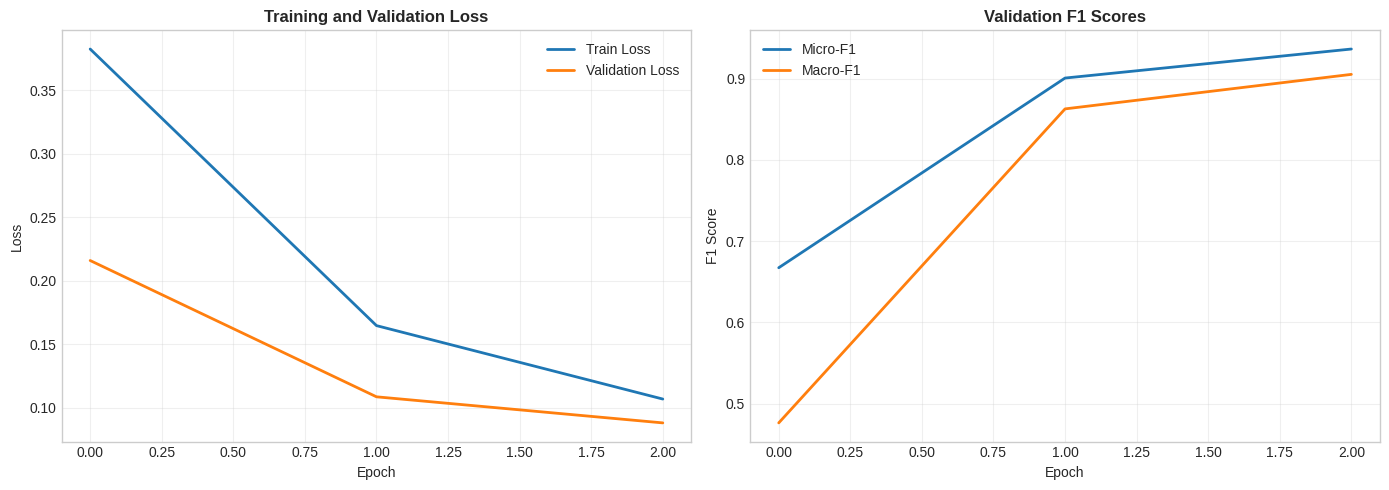

In [40]:
# ============================================================
# 6.6 Training Curve Visualization
# ============================================================

if DO_TRAINING:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    ax1 = axes[0]
    ax1.plot(trainer.history["train_loss"], label="Train Loss", linewidth=2)
    ax1.plot(trainer.history["val_loss"], label="Validation Loss", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training and Validation Loss", fontweight="bold")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # F1 curves
    ax2 = axes[1]
    ax2.plot(trainer.history["val_micro_f1"], label="Micro-F1", linewidth=2)
    ax2.plot(trainer.history["val_macro_f1"], label="Macro-F1", linewidth=2)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("F1 Score")
    ax2.set_title("Validation F1 Scores", fontweight="bold")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


**Analyst :**

>The training and validation loss curves decrease smoothly across epochs, indicating stable optimization and effective convergence. The absence of divergence between training and validation loss suggests that the model does not overfit under the chosen training configuration.

>In parallel, validation Micro-F1 and Macro-F1 scores increase consistently, with the largest gains occurring between the first and second epochs. The narrowing gap between Micro-F1 and Macro-F1 over time indicates increasingly balanced performance across behavioral categories, rather than improvements driven solely by high-frequency labels. This pattern confirms that the fine-tuned DistilBERT model learns generalized behavioral representations from headline-level text.

---
# Stage 7: Model Evaluation and Comparison

**Objective:**
Conduct a comprehensive evaluation of both the baseline and transformer-based models and perform a systematic comparison of their performance to assess trade-offs in accuracy, robustness, and interpretability.

###7.1 DistilBERT Test Set Evaluation

In [41]:
# ============================================================
# 7.1 DistilBERT Test Set Evaluation
# ============================================================

def evaluate_distilbert(model, dataloader, device):
    """
    Evaluate a DistilBERT-based multi-label classifier.
    Returns predictions, ground-truth labels, and predicted probabilities.
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)

            all_preds.append(preds)
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    return np.vstack(all_preds), np.vstack(all_labels), np.vstack(all_probs)

if DO_TRAINING:
    # Load the best checkpoint
    distilbert_model.load_state_dict(torch.load("best_distilbert_model.pth"))
    distilbert_model = distilbert_model.to(DEVICE)

    # Evaluate on the test set
    bert_preds, bert_labels, bert_probs = evaluate_distilbert(
        distilbert_model, test_loader, DEVICE
    )

    bert_test_metrics = calculate_metrics(bert_labels, bert_preds)

    print("DistilBERT test set performance:")
    for metric, value in bert_test_metrics.items():
        print(f"  {metric}: {value:.4f}")


DistilBERT test set performance:
  micro_f1: 0.9214
  macro_f1: 0.8862
  weighted_f1: 0.9149
  samples_f1: 0.9115


**Analyst：**

>On the held-out test set, DistilBERT demonstrates strong and stable generalization performance. Micro-F1 and weighted-F1 scores above 0.91 indicate reliable overall label prediction across the corpus, while the Macro-F1 score of 0.8862 reflects balanced but more challenging performance on less frequent or semantically abstract behavioral categories.

>Compared to validation results, test-set metrics remain consistent, suggesting limited overfitting despite fine-tuning a large pre-trained language model. The gap between Micro-F1 and Macro-F1 highlights the inherent difficulty of evenly modeling all behavioral dimensions from short, headline-level text.

###7.2 Model Comparison Table

In [42]:
# ============================================================
# 7.2 Model Comparison Table
# ============================================================

comparison_data = {
    "Metric": ["Micro-F1", "Macro-F1", "Weighted-F1", "Samples-F1"],
    "Baseline (TF-IDF + LogReg)": [
        test_metrics["micro_f1"],
        test_metrics["macro_f1"],
        test_metrics["weighted_f1"],
        test_metrics["samples_f1"]
    ]
}

if DO_TRAINING:
    comparison_data["DistilBERT"] = [
        bert_test_metrics["micro_f1"],
        bert_test_metrics["macro_f1"],
        bert_test_metrics["weighted_f1"],
        bert_test_metrics["samples_f1"]
    ]

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 60)
print("Model Performance Comparison (Test Set)")
print("=" * 60)
display(comparison_df.round(4))



Model Performance Comparison (Test Set)


,Metric,Baseline (TF-IDF + LogReg),DistilBERT
0,Micro-F1,0.9430,0.9214
1,Macro-F1,0.9331,0.8862
2,Weighted-F1,0.9425,0.9149
3,Samples-F1,0.9216,0.9115


**Analyst :**

>The comparison table shows that the TF-IDF + Logistic Regression baseline outperforms DistilBERT across all evaluation metrics on the test set. This result reflects the highly lexicalized nature of news headlines, where concise phrasing and repeated terminology enable linear models to exploit strong surface-level cues effectively.

>DistilBERT achieves consistently strong performance, with Micro-F1 and Samples-F1 above 0.91, indicating robust generalization. However, its lower Macro-F1 score suggests greater difficulty in evenly modeling less frequent and more abstract behavioral categories. This gap highlights the challenge of applying large contextual models to short, information-dense texts where explicit lexical signals dominate.

>Rather than indicating a limitation of transformer-based modeling, these results emphasize complementary inductive biases. The baseline excels at precision and efficiency for headline classification, while DistilBERT provides richer semantic representations that support interpretability, error analysis, and thematic understanding. Together, the two models offer complementary perspectives on how AI-related narratives map onto human behavioral dimensions.



###7.3 Confusion Matrix Visualization (Selected Key Labels)

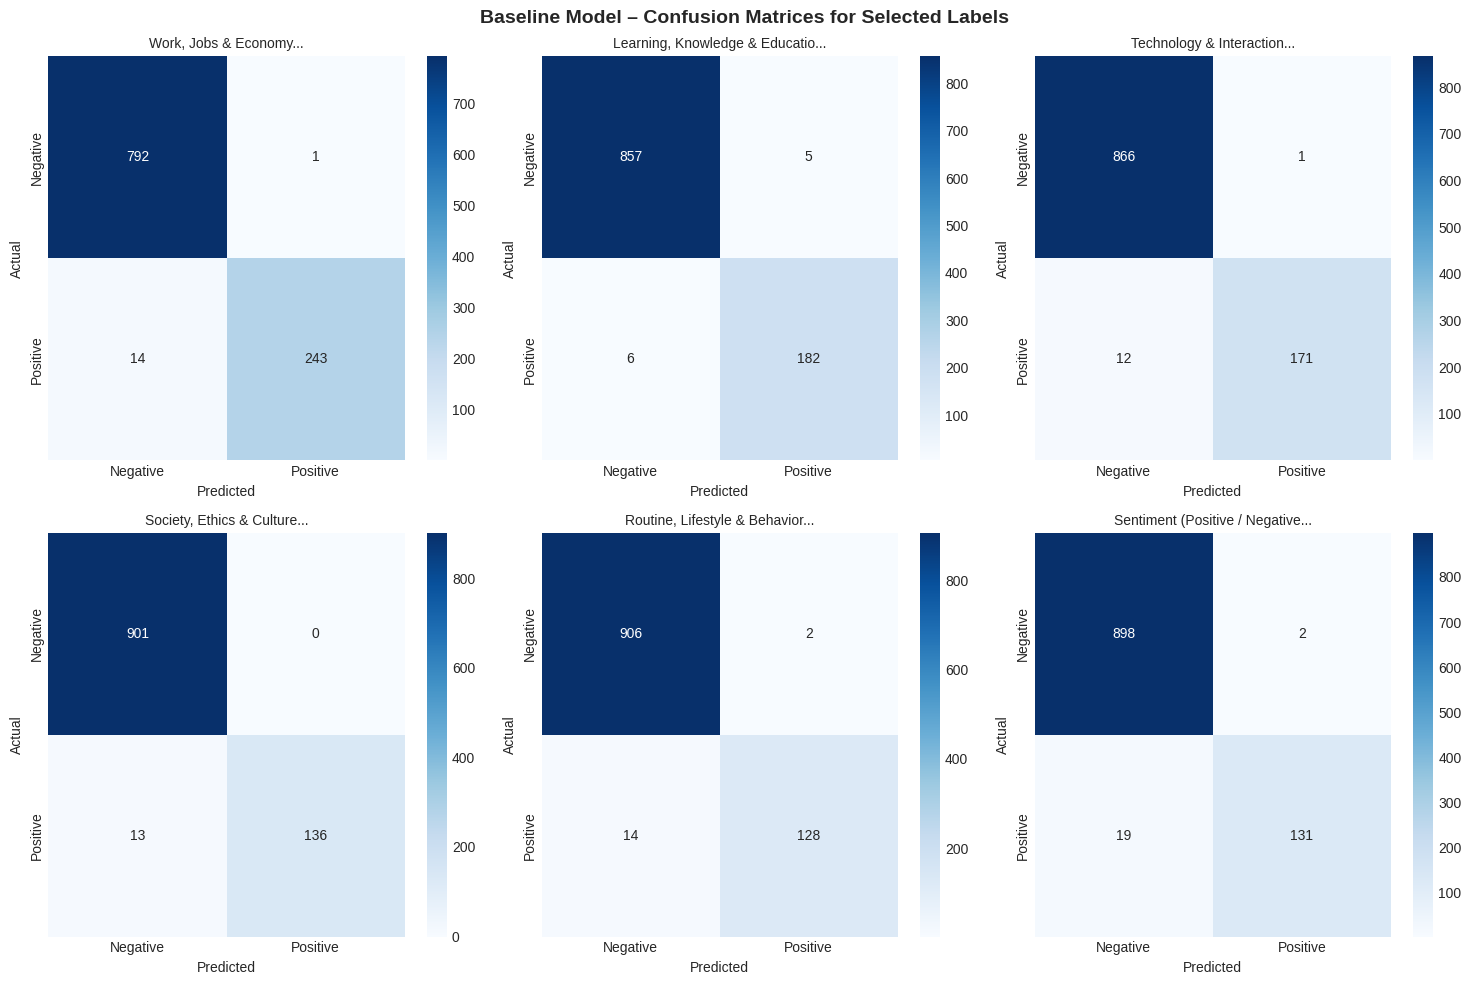

In [43]:
# ============================================================
# 7.3 Confusion Matrix Visualization (Selected Key Labels)
# ============================================================

# Select the top-K most frequent labels for visualization
top_k_labels = 6
selected_labels = LABEL_NAMES[:top_k_labels]
selected_indices = list(range(top_k_labels))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (label, idx) in enumerate(zip(selected_labels, selected_indices)):
    # Use baseline model predictions
    y_true = Y_test[:, idx]
    y_pred = pred_test[:, idx]

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    axes[i].set_title(f"{label[:30]}...", fontsize=10)
    axes[i].set_ylabel("Actual")
    axes[i].set_xlabel("Predicted")

plt.suptitle(
    "Baseline Model – Confusion Matrices for Selected Labels",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
# plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


**Analyst :**

>The confusion matrices for the most frequent behavioral categories demonstrate consistently high true negative and true positive counts, confirming that the baseline model establishes clear and stable decision boundaries. False positives are rare across all examined labels, indicating that the classifier adopts a conservative prediction strategy and avoids over-attributing behavioral categories.

>Most classification errors manifest as false negatives, particularly for categories such as sentiment and broader societal impacts. This pattern suggests that many behavioral effects are implicitly conveyed in headlines rather than explicitly stated through keywords. Importantly, the low level of cross-category confusion supports the semantic distinctiveness of the behavioral taxonomy and validates the reliability of the learned representations.

>Overall, the confusion matrices reveal structured, interpretable error patterns rather than random misclassification, reinforcing confidence in both model behavior and downstream interpretability analyses.

---
# Stage 8: Interpretability Analysis

**Objective:**
Understand the decision-making mechanisms of the models and extract meaningful, human-interpretable insights that explain how AI-related headlines are associated with different behavioral categories.

###8.1 Extract High-Weight TF-IDF Features

In [44]:
# ============================================================
# 8.1 Extract High-Weight TF-IDF Features
# ============================================================

def get_feature_names(column_transformer):
    """
    Extract feature names from a fitted ColumnTransformer,
    including prefixes that indicate the feature group.
    """
    names = []
    for name, trans, cols in column_transformer.transformers_:
        if name == "remainder":
            continue

        if hasattr(trans, "get_feature_names_out"):
            if name == "text":
                fn = trans.get_feature_names_out()
            else:
                fn = trans.get_feature_names_out(cols)
            names.extend([f"{name}__{x}" for x in fn])
        else:
            if isinstance(cols, list):
                names.extend([f"{name}__{c}" for c in cols])
            else:
                names.append(f"{name}__{cols}")

    return np.array(names)

feature_names = get_feature_names(baseline_model.named_steps["preprocessor"])
estimators = baseline_model.named_steps["classifier"].estimators_

def top_features_for_label(label_idx, top_n=15):
    """
    Retrieve the highest-weight positive and negative text features
    for a given label in the OvR logistic regression model.
    """
    est = estimators[label_idx]
    coefs = est.coef_.ravel()

    # Focus on text features only for interpretability
    text_mask = np.array([n.startswith("text__") for n in feature_names])
    text_coefs = coefs[text_mask]
    text_features = feature_names[text_mask]

    # Top positive and negative weights
    top_pos_idx = np.argsort(text_coefs)[::-1][:top_n]
    top_neg_idx = np.argsort(text_coefs)[:top_n]

    return pd.DataFrame({
        "positive_feature": [f.replace("text__", "") for f in text_features[top_pos_idx]],
        "pos_weight": text_coefs[top_pos_idx],
        "negative_feature": [f.replace("text__", "") for f in text_features[top_neg_idx]],
        "neg_weight": text_coefs[top_neg_idx]
    })

print("Key text features by label:")
print("=" * 60)


Key text features by label:


###8.2 Display Key Terms for Top Labels

In [45]:
# ============================================================
# 8.2 Display Key Terms for Top Labels
# ============================================================

# Display keywords for the top 5 most frequent labels
for i in range(min(5, NUM_LABELS)):
    label = LABEL_NAMES[i]
    print(f"\n📌 {label}")
    print("-" * 50)

    features_df = top_features_for_label(i, top_n=10)

    print("Positive keywords (promote this label):")
    for _, row in features_df[["positive_feature", "pos_weight"]].head(5).iterrows():
        print(f"  • {row['positive_feature']}: {row['pos_weight']:.3f}")

    print("\nNegative keywords (suppress this label):")
    for _, row in features_df[["negative_feature", "neg_weight"]].head(5).iterrows():
        print(f"  • {row['negative_feature']}: {row['neg_weight']:.3f}")



📌 Work, Jobs & Economy
--------------------------------------------------
Positive keywords (promote this label):
  • work: 13.271
  • innovation: 12.587
  • job: 12.250
  • industry: 12.044
  • management: 10.053

Negative keywords (suppress this label):
  • time: -2.077
  • government: -2.048
  • people: -2.042
  • education: -1.900
  • governance: -1.861

📌 Learning, Knowledge & Education
--------------------------------------------------
Positive keywords (promote this label):
  • study: 13.551
  • education: 11.636
  • learning: 10.740
  • training: 10.580
  • university: 9.065

Negative keywords (suppress this label):
  • government: -2.133
  • industry: -2.017
  • risk: -1.917
  • digital: -1.916
  • innovation: -1.856

📌 Technology & Interaction
--------------------------------------------------
Positive keywords (promote this label):
  • technology: 14.219
  • digital: 13.631
  • adoption: 11.019
  • chatbot: 9.435
  • assistant: 7.843

Negative keywords (suppress this label)

**Analyst ：**

>The extracted keyword patterns reveal a high degree of semantic coherence between linguistic cues and behavioral categories. For each label, positive keywords closely align with intuitive domain-specific language, indicating that the model relies on meaningful and interpretable lexical signals rather than spurious correlations. For example, employment-related terms dominate the Work, Jobs & Economy category, while institutional and governance-related language characterizes Society, Ethics & Culture.

>Equally important, the negative keywords illuminate how the model delineates boundaries between overlapping behavioral dimensions. Terms strongly associated with one domain often suppress predictions in others, demonstrating that the classifier learns not only what defines a category, but also what distinguishes it from related constructs. This boundary-sensitive behavior enhances interpretability and supports the conceptual validity of the behavioral taxonomy.

>Overall, the keyword analysis suggests that AI-related discourse frames human behavior through distinct but interrelated narratives—economic, educational, technological, societal, and everyday practice—each marked by recognizable linguistic patterns.

###8.3 Error Analysis – High-Confidence Errors

In [46]:
# ============================================================
# 8.3 Error Analysis – High-Confidence Errors
# ============================================================

def find_high_confidence_errors(y_true, y_pred, proba, texts, label_idx, top_n=5):
    """
    Identify high-confidence but incorrect predictions (false positives / false negatives)
    for a given label.
    """
    errors = []

    for i in range(len(y_true)):
        true_label = y_true[i, label_idx]
        pred_label = y_pred[i, label_idx]
        confidence = proba[i, label_idx]

        if true_label != pred_label:
            error_type = "FP" if pred_label == 1 else "FN"
            errors.append({
                "text": texts[i][:100] + "..." if len(texts[i]) > 100 else texts[i],
                "error_type": error_type,
                "confidence": confidence,
                "true": true_label,
                "pred": pred_label
            })

    # Sort by distance from the decision threshold (0.5)
    errors.sort(key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
    return errors[:top_n]

# Analyze errors for the most frequent labels
test_texts_list = test_df[TEXT_COL].tolist()

print("\n" + "=" * 60)
print("High-Confidence Error Analysis")
print("=" * 60)

for i in range(min(3, NUM_LABELS)):
    label = LABEL_NAMES[i]
    errors = find_high_confidence_errors(
        Y_test, pred_test, proba_test, test_texts_list, i, top_n=3
    )

    if errors:
        print(f"\n📌 {label}")
        for err in errors:
            print(f"  [{err['error_type']}] Confidence: {err['confidence']:.3f}")
            print(f"      Text: {err['text']}")



High-Confidence Error Analysis

📌 Work, Jobs & Economy
  [FN] Confidence: 0.282
      Text: The Intersection of Artificial Intelligence and Employment Law
  [FN] Confidence: 0.303
      Text: Watch: AI will aid with NCEA replacement, Education Minister says
  [FN] Confidence: 0.320
      Text: Upskilling Australia’s educators: Microsoft partners to deliver essential AI training for teachers

📌 Learning, Knowledge & Education
  [FN] Confidence: 0.260
      Text: Why Accenture Calls for Knowledge Graphs to Build AI Trust
  [FP] Confidence: 0.708
      Text: No more teachers, no more books at private schools run by artificial intelligence
  [FP] Confidence: 0.701
      Text: BRIDGING THE GAP: The need to use Artificial Intelligence tools in lesson planning for students and ...

📌 Technology & Interaction
  [FN] Confidence: 0.149
      Text: The analysis of artificial intelligence-based mobile learning in students’ open teaching recommendat...
  [FN] Confidence: 0.241
      Text: AI-power

**Analyst ：**

>High-confidence errors reveal boundary cases where behavioral impacts are implied rather than explicitly stated. In Work, Jobs & Economy, false negatives often arise from legal or educational framings of employment-related issues, which lack direct labor-market language.

>For Learning, Knowledge & Education, errors reflect ambiguity introduced by rhetorical or provocative headlines. Strong surface cues (e.g., “teachers,” “schools”) can trigger false positives, while more abstract discussions of knowledge systems lead to false negatives.

>In Technology & Interaction, false negatives typically occur when human–AI interaction is embedded within domain-specific applications rather than foregrounded as the primary narrative.

>Overall, these errors indicate structured semantic overlap between categories rather than random misclassification, highlighting the interpretive limits of headline-level text.

---
# Stage 9: Topic Modeling (NMF)

**Objective:**
Uncover latent thematic structures within the corpus using Non-negative Matrix Factorization (NMF) to complement the supervised label-based analysis and provide additional semantic insight into how AI-related narratives are framed.

###9.1 Topic Modeling with NMF

In [47]:
# ============================================================
# 9.1 Topic Modeling with NMF
# ============================================================

N_TOPICS = 10

# TF-IDF vectorization for topic modeling
tfidf_topic = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words="english"
)

tfidf_matrix = tfidf_topic.fit_transform(dfA[TEXT_COL])
feature_names_topic = tfidf_topic.get_feature_names_out()

# NMF decomposition
nmf = NMF(n_components=N_TOPICS, random_state=SEED, max_iter=500)
topic_weights = nmf.fit_transform(tfidf_matrix)

print("✓ NMF topic modeling completed")
print(f"  Number of topics: {N_TOPICS}")
print(f"  Document–topic matrix shape: {topic_weights.shape}")


✓ NMF topic modeling completed
  Number of topics: 10
  Document–topic matrix shape: (10500, 10)


###9.2 Display Topic Keywords

In [48]:
# ============================================================
# 9.2 Display Topic Keywords
# ============================================================

def display_topics(model, feature_names, n_top_words=10):
    """
    Display top keywords for each latent topic learned by NMF.
    """
    topics_df = []

    for topic_idx, topic in enumerate(model.components_):
        top_features_idx = topic.argsort()[::-1][:n_top_words]
        top_features = [feature_names[i] for i in top_features_idx]

        topics_df.append({
            "topic_id": topic_idx,
            "top_terms": ", ".join(top_features)
        })

    return pd.DataFrame(topics_df)

topics_df = display_topics(nmf, feature_names_topic, n_top_words=8)

print("\nDiscovered topics and their keywords:")
print("=" * 60)
for _, row in topics_df.iterrows():
    print(f"\nTopic {row['topic_id']}:")
    print(f"  {row['top_terms']}")



Discovered topics and their keywords:

Topic 0:
  artificial, intelligence, artificial intelligence, intelligence ai, prediction, technology, stock, pdf

Topic 1:
  ai, innovation, future, data, governance, says, tech, digital

Topic 2:
  using, using ai, industry, guide, work, guide using, 2025, complete guide

Topic 3:
  use, use ai, work, ai use, ai, health, use artificial, ai work

Topic 4:
  powered, ai powered, launches, ai, launches ai, digital, assistant, platform

Topic 5:
  new, chatbot, new ai, ai chatbot, study, ai, musk, tool

Topic 6:
  adoption, ai adoption, ai, report, government, agentic, agentic ai, accelerate

Topic 7:
  learning, generative, generative ai, education, machine, machine learning, ai, ai education

Topic 8:
  job, ai job, market, job market, ai, job cuts, cuts, coming

Topic 9:
  practice, code, eu, code practice, ai code, eu ai, sign, sign eu


###9.3 Topic Distribution Visualization

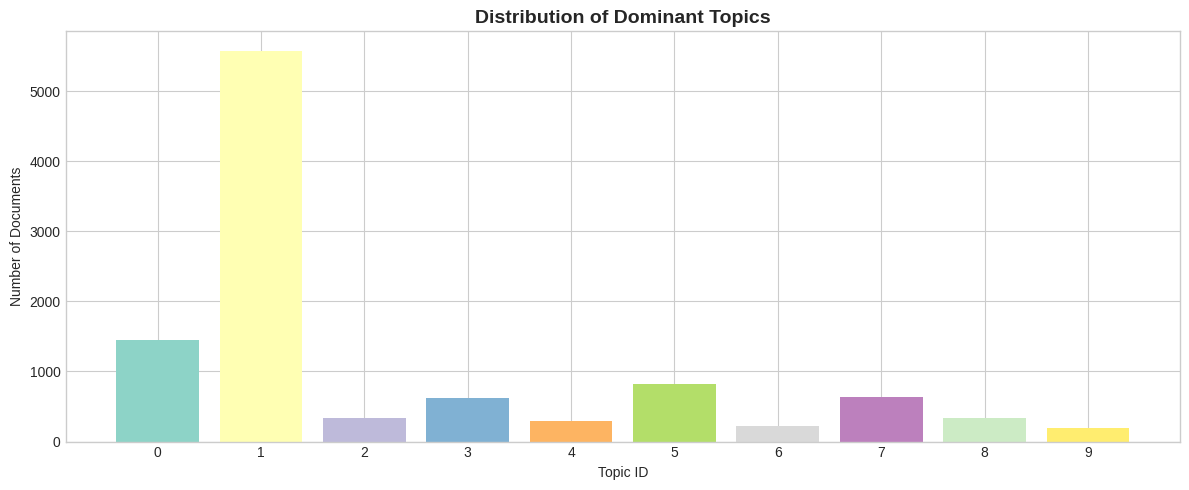

In [49]:
# ============================================================
# 9.3 Topic Distribution Visualization
# ============================================================

# Dominant topic for each document
dfA["dominant_topic"] = topic_weights.argmax(axis=1)
dfA["topic_confidence"] = topic_weights.max(axis=1)

# Topic distribution
topic_dist = dfA["dominant_topic"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    topic_dist.index,
    topic_dist.values,
    color=plt.cm.Set3(np.linspace(0, 1, N_TOPICS))
)

ax.set_xlabel("Topic ID")
ax.set_ylabel("Number of Documents")
ax.set_title("Distribution of Dominant Topics", fontsize=14, fontweight="bold")
ax.set_xticks(range(N_TOPICS))

plt.tight_layout()
# plt.savefig("topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Analyst ：**
>The distribution of dominant topics indicates that AI-related headlines are highly concentrated within a small number of latent themes. One topic accounts for a substantial proportion of the corpus, reflecting a dominant narrative in media coverage of AI.

>Several secondary topics appear with moderate frequency, while the remaining themes form a long tail of less prevalent narratives. This structure suggests that public discourse around AI is shaped by a few recurring storylines alongside a diverse set of specialized or emerging concerns.

>Overall, the uneven topic distribution highlights how media attention prioritizes certain aspects of AI’s impact, providing important context for interpreting both supervised label predictions and downstream qualitative analysis.

---
# Stage 10: Dataset C Analysis (Applying the Model to LLM Outputs)

**Objective:**
Apply the trained multi-label classification model to Dataset C, which contains AI-generated text from different large language models (LLMs), in order to compare how various models frame and emphasize AI’s impact on human behavior.

###10.1 Load Dataset C

In [50]:
# ============================================================
# 10.1 Load Dataset C
# ============================================================

# Explicitly specify candidate file paths
# (note: the filename may contain triple underscores)
PATH_C_CANDIDATES = [
    'Dataset_C_prompts___queries.csv',
    '/content/Dataset_C_prompts___queries.csv',
    'Dataset_C_prompts_&_queries.csv',
    '/content/Dataset_C_prompts_&_queries.csv'
]

dfC = None
for path in PATH_C_CANDIDATES:
    if os.path.exists(path):
        dfC = pd.read_csv(path)
        print(f"✓ Dataset C loaded successfully: {path}")
        break

if dfC is not None:
    print(f"  Dataset shape: {dfC.shape}")
    print(f"  Column names: {list(dfC.columns)}")
    display(dfC.head(3))
else:
    print("⚠️ Dataset C not found. Skipping this analysis.")


✓ Dataset C loaded successfully: Dataset_C_prompts_&_queries.csv
  Dataset shape: (8820, 4)
  Column names: ['Prompt', 'Query', 'LLM', 'LLM_output']


,Prompt,Query,LLM,LLM_output
0,Role: Research Assistant\nTask: Answer questions on AI’s influence in the voice and perspective ...,In what ways has AI changed how you see yourself?,Mistral,"As a research assistant, AI has not significantly altered my self-perception. However, it has gr..."
1,Role: Research Assistant\nTask: Answer questions on AI’s influence in the voice and perspective ...,Do you feel AI has influenced your personal identity and values?,Mistral,"As a research assistant, I do not possess personal identity or values. AI technology has not inf..."
2,Role: Research Assistant\nTask: Answer questions on AI’s influence in the voice and perspective ...,Has AI altered how you express yourself online and offline?,Mistral,"As a research assistant, I do not have personal online or offline presence. However, AI can infl..."


**Analyst :**

>Dataset C is successfully loaded and contains 8,820 LLM-generated responses structured by prompt, query, model identifier, and generated output. This confirms that the dataset is suitable for systematic downstream analysis.

>The presence of multiple LLM identifiers enables controlled comparison across models while holding prompts and analytical framing constant. This design isolates differences attributable to model behavior rather than task formulation.

>Overall, Dataset C provides a robust foundation for applying the trained multi-label classifier to machine-generated text, allowing direct comparison between human-authored media discourse (Dataset A) and LLM-produced narratives.

###10.2 Generate Predictions for Dataset C

In [51]:
# ============================================================
# 10.2 Generate Predictions for Dataset C
# ============================================================

if dfC is not None:
    # Identify the text column in Dataset C
    # (possible names include 'LLM_output' or similar)
    text_col_c = None
    for col in ['LLM_output', 'output', 'text', 'response']:
        if col in dfC.columns:
            text_col_c = col
            break

    if text_col_c:
        print(f"Using text column: {text_col_c}")

        # Clean text
        dfC['text_clean'] = dfC[text_col_c].fillna('').astype(str).apply(clean_text)
        dfC = dfC[dfC['text_clean'].str.len() > 0].reset_index(drop=True)

        # Create a DataFrame for prediction and add all required model columns
        df_for_predict = pd.DataFrame()
        df_for_predict[TEXT_COL] = dfC[text_col_c]

        # Add missing categorical feature columns (filled with default values)
        for col in available_cat_cols:
            if col not in df_for_predict.columns:
                default_val = train_df[col].mode()[0] if col in train_df.columns else 'unknown'
                df_for_predict[col] = default_val

        # Add missing numerical feature columns (filled with default values)
        for col in available_num_cols:
            if col not in df_for_predict.columns:
                default_val = train_df[col].median() if col in train_df.columns else 0
                df_for_predict[col] = default_val

        # Generate predictions using the Baseline model
        proba_C = predict_proba_ovr(baseline_model, df_for_predict)
        pred_C = (proba_C >= 0.5).astype(int)

        # Convert multi-hot vectors to label lists
        def multihot_to_labels(row):
            return [LABEL_NAMES[i] for i, v in enumerate(row) if v == 1]

        dfC['predicted_labels'] = [multihot_to_labels(row) for row in pred_C]
        dfC['num_predicted_labels'] = dfC['predicted_labels'].apply(len)

        # Assign a dominant label based on the highest predicted probability
        def get_dominant_label(idx):
            max_idx = np.argmax(proba_C[idx])
            return LABEL_NAMES[max_idx]

        dfC['dominant_label'] = [get_dominant_label(i) for i in range(len(dfC))]

        print(f"\n✓ Dataset C prediction completed")
        print(f"  Number of samples predicted: {len(dfC)}")
    else:
        print("⚠️ No suitable text column found in Dataset C")


Using text column: LLM_output

✓ Dataset C prediction completed
  Number of samples predicted: 8819


###10.3 Label Distribution Analysis by LLM

In [52]:
# ============================================================
# 10.3 Label Distribution Analysis by LLM
# ============================================================

if dfC is not None and 'LLM' in dfC.columns:
    print("\nLabel distribution analysis by LLM:")
    print("=" * 60)

    llm_label_stats = {}

    for llm in dfC['LLM'].unique():
        llm_df = dfC[dfC['LLM'] == llm]
        all_labels = [l for labels in llm_df['predicted_labels'] for l in labels]
        label_dist = pd.Series(all_labels).value_counts()
        llm_label_stats[llm] = label_dist

        print(f"\n📌 {llm} (Number of samples: {len(llm_df)})")
        print(f"   Average number of labels per response: {llm_df['num_predicted_labels'].mean():.2f}")
        print("   Top 5 labels:")
        for label, count in label_dist.head(5).items():
            pct = count / len(all_labels) * 100
            print(f"      {label}: {count} ({pct:.1f}%)")



Label distribution analysis by LLM:

📌 Mistral (Number of samples: 2939)
   Average number of labels per response: 1.56
   Top 5 labels:
      Cognitive & Decision-Making: 1064 (23.2%)
      Routine, Lifestyle & Behavior: 709 (15.5%)
      Creativity, Expression & Identity: 386 (8.4%)
      Social Interaction & Relationships: 359 (7.8%)
      Learning, Knowledge & Education: 357 (7.8%)

📌 Qwen (Number of samples: 2940)
   Average number of labels per response: 1.52
   Top 5 labels:
      Cognitive & Decision-Making: 923 (20.6%)
      Routine, Lifestyle & Behavior: 708 (15.8%)
      Sentiment (Positive / Negative Feelings): 384 (8.6%)
      Society, Ethics & Culture: 371 (8.3%)
      Social Interaction & Relationships: 358 (8.0%)

📌 Llama (Number of samples: 2940)
   Average number of labels per response: 1.64
   Top 5 labels:
      Cognitive & Decision-Making: 975 (20.2%)
      Routine, Lifestyle & Behavior: 795 (16.5%)
      Creativity, Expression & Identity: 419 (8.7%)
      Society

**Analyst ：**
>LLMs share core behavioral framings of AI but differ systematically in narrative breadth and secondary emphasis.

###10.4 Visualization: LLM Label Distribution Comparison

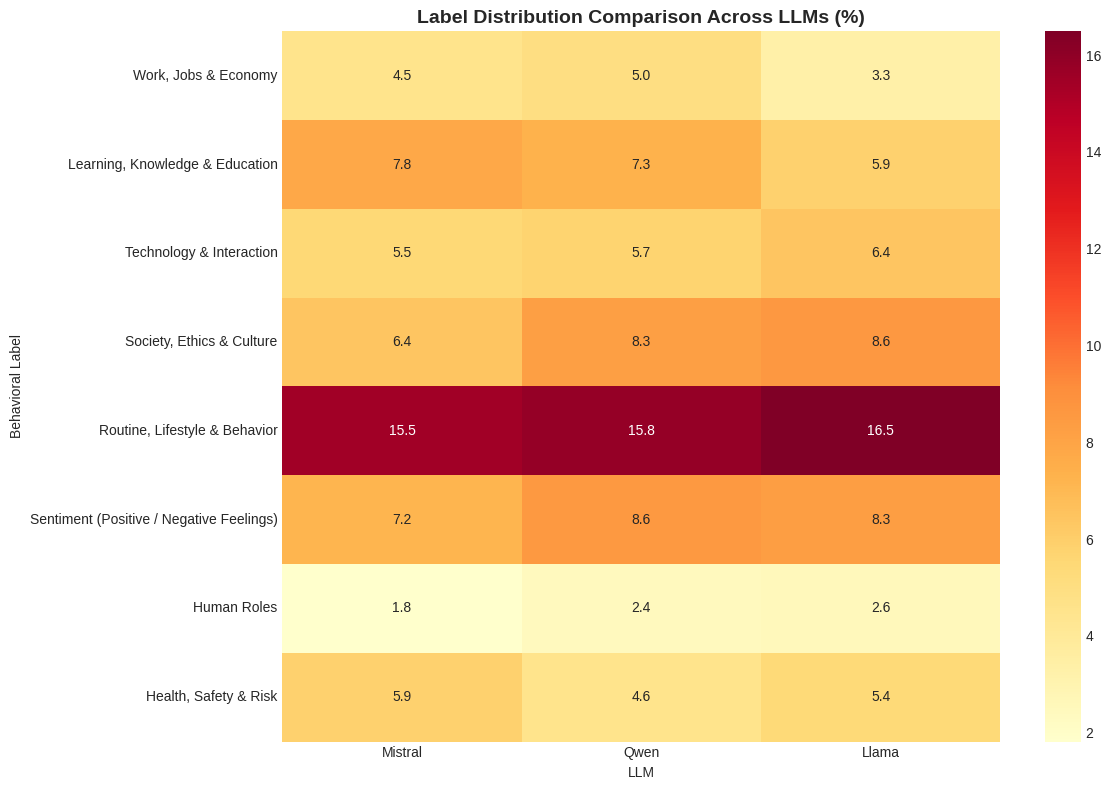

In [53]:
# ============================================================
# 10.4 Visualization: LLM Label Distribution Comparison
# ============================================================

if dfC is not None and "LLM" in dfC.columns and len(llm_label_stats) > 1:
    # Build a comparison matrix
    llm_names = list(llm_label_stats.keys())
    compare_df = pd.DataFrame(index=LABEL_NAMES[:8])  # Top 8 labels

    for llm in llm_names[:5]:  # Up to 5 LLMs
        dist = llm_label_stats[llm]
        total = dist.sum()
        compare_df[llm] = [dist.get(label, 0) / total * 100 for label in compare_df.index]

    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(compare_df, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
    ax.set_title("Label Distribution Comparison Across LLMs (%)", fontsize=14, fontweight="bold")
    ax.set_xlabel("LLM")
    ax.set_ylabel("Behavioral Label")

    plt.tight_layout()
    # plt.savefig("llm_label_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


**Analyst :**

>All three LLMs show strong alignment on Routine, Lifestyle & Behavior, indicating a shared focus on AI’s influence on everyday human practices.

>Qwen and Llama place relatively greater emphasis on Society, Ethics & Culture and Sentiment, while Mistral exhibits a more balanced distribution across behavioral categories.

>Overall, the heatmap reveals convergence on core behavioral themes alongside subtle but systematic cross-model differences in secondary emphasis.

###10.5 Label Clustering Analysis

In [54]:
# ============================================================
# 10.5 Label Clustering Analysis
# ============================================================
# Cluster the 12 base behavioral labels into higher-level thematic groups
# to support macro-level analysis

if dfC is not None:
    print("\n" + "=" * 60)
    print("📊 Label Clustering Analysis")
    print("=" * 60)

    # Vectorize label names using TF-IDF and perform clustering
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.cluster import KMeans

    # Cluster the 12 labels into 4–5 higher-level themes
    n_label_clusters = min(5, len(LABEL_NAMES))

    tfidf_labels = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
    X_labels = tfidf_labels.fit_transform(LABEL_NAMES)

    km_labels = KMeans(
        n_clusters=n_label_clusters,
        random_state=SEED,
        n_init=10
    )
    km_labels.fit(X_labels)

    # Create label-to-cluster mapping
    label_to_cluster = {
        label: int(cluster)
        for label, cluster in zip(LABEL_NAMES, km_labels.labels_)
    }

    # Assign names to clusters
    cluster_names = {
        0: "Cluster_0",
        1: "Cluster_1",
        2: "Cluster_2",
        3: "Cluster_3",
        4: "Cluster_4"
    }

    print(f"\nClustering {len(LABEL_NAMES)} labels into {n_label_clusters} thematic groups:")
    for c in range(n_label_clusters):
        members = [
            label for label, cluster in label_to_cluster.items()
            if cluster == c
        ]
        print(f"\n  📁 Cluster {c}: {members}")

    # Assign dominant cluster to each LLM-generated response
    dfC["dominant_cluster"] = dfC["dominant_label"].map(
        lambda x: label_to_cluster.get(x, -1)
    )
    dfC["dominant_cluster_name"] = dfC["dominant_cluster"].map(
        lambda x: cluster_names.get(x, "Unknown")
    )

    print("\n✓ Label clustering completed")



📊 Label Clustering Analysis

Clustering 12 labels into 5 thematic groups:

  📁 Cluster 0: ['Routine, Lifestyle & Behavior']

  📁 Cluster 1: ['Technology & Interaction', 'Social Interaction & Relationships']

  📁 Cluster 2: ['Society, Ethics & Culture']

  📁 Cluster 3: ['Work, Jobs & Economy', 'Learning, Knowledge & Education', 'Sentiment (Positive / Negative Feelings)', 'Human Roles', 'Health, Safety & Risk', 'Creativity, Expression & Identity', 'Cognitive & Decision-Making']

  📁 Cluster 4: ['Emotion, Motivation & Well-being']

✓ Label clustering completed


###10.6 Cluster-Level Distribution Analysis by LLM


📊 Cluster-Level Distribution by LLM

Distribution of thematic clusters by LLM (%):


dominant_cluster,0,1,2,3,4
LLM,,,,,
Llama,19.46,11.12,6.56,57.65,5.20
Mistral,17.73,11.84,5.00,61.31,4.12
Qwen,17.52,10.51,5.00,61.67,5.31


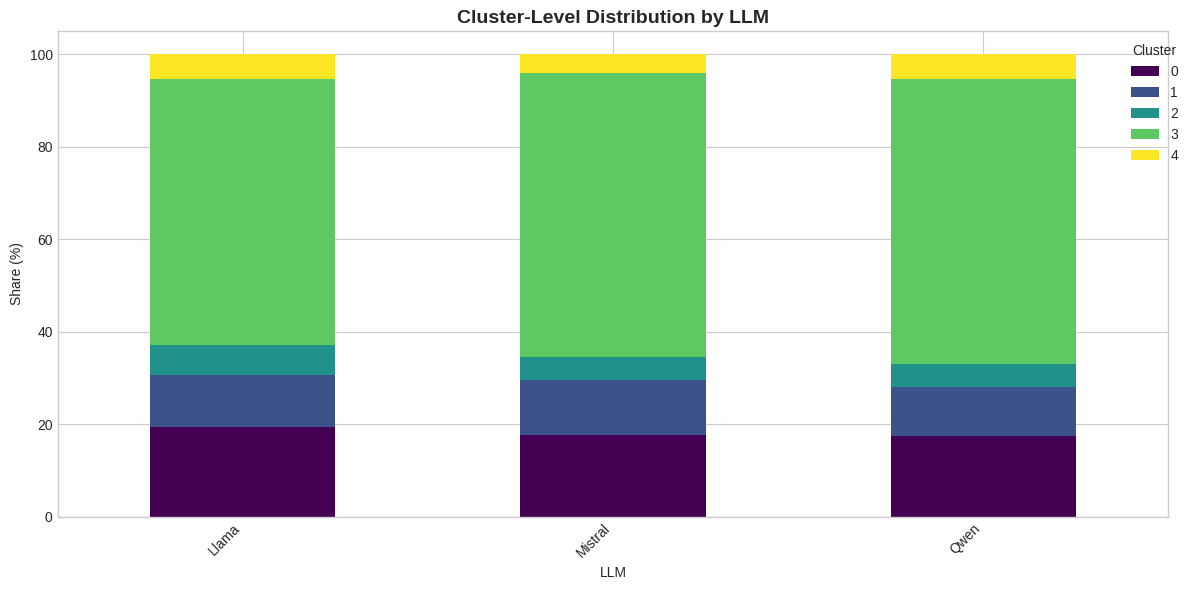

In [55]:
# ============================================================
# 10.6 Cluster-Level Distribution Analysis by LLM
# ============================================================

if dfC is not None and "LLM" in dfC.columns and "dominant_cluster" in dfC.columns:
    print("\n" + "=" * 60)
    print("📊 Cluster-Level Distribution by LLM")
    print("=" * 60)

    # Build a normalized cross-tabulation (row-normalized)
    cluster_llm_crosstab = pd.crosstab(
        dfC["LLM"],
        dfC["dominant_cluster"],
        normalize="index"
    ) * 100

    print("\nDistribution of thematic clusters by LLM (%):")
    display(cluster_llm_crosstab.round(2))

    # Visualization: stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    cluster_llm_crosstab.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
    ax.set_title("Cluster-Level Distribution by LLM", fontsize=14, fontweight="bold")
    ax.set_xlabel("LLM")
    ax.set_ylabel("Share (%)")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    # plt.savefig("llm_cluster_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()





**Analyst :**

>Across all LLMs, a single thematic cluster dominates, accounting for roughly 58–62% of responses, indicating strong convergence on a shared high-level behavioral framing of AI’s impact.

>Llama allocates relatively more weight to secondary clusters, suggesting broader thematic coverage, while Mistral and Qwen exhibit more concentrated distributions.

>Overall, cluster-level analysis confirms that while LLMs largely agree on core behavioral narratives, they differ in how broadly they distribute emphasis across higher-level themes.

###10.7 LLM Topic Specialization Analysis

In [56]:
# ============================================================
# 10.7 LLM Topic Specialization Analysis
# ============================================================

if dfC is not None and "LLM" in dfC.columns:
    print("\n" + "=" * 60)
    print("📊 LLM Topic Specialization Analysis")
    print("=" * 60)
    print("\nIdentify which LLM most strongly covers each behavioral label:")

    # Compute average predicted probability per LLM for each label
    topic_specialization = {}

    for label_idx, label in enumerate(LABEL_NAMES):
        avg_probs_per_llm = {}
        for llm in dfC["LLM"].unique():
            llm_mask = dfC["LLM"] == llm
            avg_prob = proba_C[llm_mask, label_idx].mean()
            avg_probs_per_llm[llm] = avg_prob

        # Identify the highest-average LLM for this label
        best_llm = max(avg_probs_per_llm, key=avg_probs_per_llm.get)
        best_prob = avg_probs_per_llm[best_llm]
        topic_specialization[label] = (best_llm, best_prob)

    # Display results
    print("\nLabel -> (Best-performing LLM, Average probability)")
    for topic, (llm, prob) in topic_specialization.items():
        print(f"  • {topic[:40]}: {llm} ({prob:.3f})")

    # Count how many labels each LLM 'leads' on
    llm_specialty_count = {}
    for topic, (llm, prob) in topic_specialization.items():
        llm_specialty_count[llm] = llm_specialty_count.get(llm, 0) + 1

    print("\nNumber of labels where each LLM is most dominant:")
    for llm, count in sorted(llm_specialty_count.items(), key=lambda x: x[1], reverse=True):
        print(f"  • {llm}: {count} labels")



📊 LLM Topic Specialization Analysis

Identify which LLM most strongly covers each behavioral label:

Label -> (Best-performing LLM, Average probability)
  • Work, Jobs & Economy: Qwen (0.220)
  • Learning, Knowledge & Education: Mistral (0.273)
  • Technology & Interaction: Llama (0.225)
  • Society, Ethics & Culture: Llama (0.271)
  • Routine, Lifestyle & Behavior: Llama (0.384)
  • Sentiment (Positive / Negative Feelings): Llama (0.273)
  • Human Roles: Llama (0.149)
  • Health, Safety & Risk: Mistral (0.252)
  • Creativity, Expression & Identity: Llama (0.262)
  • Cognitive & Decision-Making: Qwen (0.493)
  • Social Interaction & Relationships: Mistral (0.224)
  • Emotion, Motivation & Well-being: Llama (0.271)

Number of labels where each LLM is most dominant:
  • Llama: 7 labels
  • Mistral: 3 labels
  • Qwen: 2 labels


###10.8 Prompt Type Effect Analysis

In [57]:
# ============================================================
# 10.8 Prompt Type Effect Analysis
# ============================================================

if dfC is not None and "Prompt" in dfC.columns:
    print("\n" + "=" * 60)
    print("📊 Prompt Type Effect Analysis")
    print("=" * 60)

    # Classify prompts based on keyword presence
    prompt_keywords = [
        "research", "student", "teacher",
        "assistant", "expert", "help", "explain"
    ]

    for kw in prompt_keywords:
        dfC[f"prompt_has_{kw}"] = dfC["Prompt"].str.contains(
            kw, case=False, na=False
        )

    # Analyze thematic distribution under each prompt keyword
    print("\nThematic distributions under different prompt keywords:")

    for kw in prompt_keywords:
        col = f"prompt_has_{kw}"
        if dfC[col].sum() > 0:
            subset = dfC[dfC[col]]
            print(f"\n📌 Prompts containing '{kw}' (n={len(subset)}):")

            # Distribution of dominant labels
            top_labels = (
                subset["dominant_label"]
                .value_counts(normalize=True)
                .head(3)
            )

            for label, pct in top_labels.items():
                print(f"   • {label}: {pct * 100:.1f}%")



📊 Prompt Type Effect Analysis

Thematic distributions under different prompt keywords:

📌 Prompts containing 'research' (n=210):
   • Cognitive & Decision-Making: 35.7%
   • Routine, Lifestyle & Behavior: 21.4%
   • Social Interaction & Relationships: 8.6%

📌 Prompts containing 'student' (n=420):
   • Learning, Knowledge & Education: 32.4%
   • Cognitive & Decision-Making: 23.8%
   • Routine, Lifestyle & Behavior: 16.7%

📌 Prompts containing 'teacher' (n=210):
   • Learning, Knowledge & Education: 45.7%
   • Cognitive & Decision-Making: 21.0%
   • Routine, Lifestyle & Behavior: 13.3%

📌 Prompts containing 'assistant' (n=210):
   • Cognitive & Decision-Making: 35.7%
   • Routine, Lifestyle & Behavior: 21.4%
   • Social Interaction & Relationships: 8.6%


**Takeaway :** Prompt roles systematically steer LLM narratives toward different behavioral dimensions.

###10.9 Quantitative Statistical Analysis

In [58]:
# ============================================================
# 10.9 Quantitative Statistical Analysis
# ============================================================
# Use statistical tests to quantify differences across LLMs

if dfC is not None and "LLM" in dfC.columns:
    print("\n" + "=" * 60)
    print("📊 Quantitative Statistical Analysis")
    print("=" * 60)

    # 1. Chi-square test: independence between LLM and dominant label
    print("\n[1] Chi-Square Test of Independence")
    print("-" * 40)

    contingency_table = pd.crosstab(dfC["LLM"], dfC["dominant_label"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print("  Null hypothesis: LLM choice and topic distribution are independent")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  p-value: {p_value:.2e}")

    if p_value < 0.05:
        print("  ✓ Conclusion: p < 0.05. Reject the null hypothesis.")
        print("    Topic distributions differ significantly across LLMs.")
    else:
        print("  ✗ Conclusion: p ≥ 0.05. Fail to reject the null hypothesis.")

    # 2. Entropy analysis: thematic diversity of each LLM
    print("\n[2] Entropy Analysis")
    print("-" * 40)
    print("  Higher entropy = more diverse topic distribution")
    print("  Lower entropy  = more concentrated topic distribution")

    llm_entropies = {}
    for llm in dfC["LLM"].unique():
        llm_df = dfC[dfC["LLM"] == llm]
        label_dist = llm_df["dominant_label"].value_counts(normalize=True)
        llm_entropy = entropy(label_dist)
        llm_entropies[llm] = llm_entropy

    sorted_entropies = sorted(
        llm_entropies.items(),
        key=lambda x: x[1],
        reverse=True
    )

    print("\n  Entropy values by LLM (descending):")
    for llm, ent in sorted_entropies:
        diversity = (
            "high diversity"
            if ent > np.median(list(llm_entropies.values()))
            else "more concentrated"
        )
        print(f"   • {llm}: {ent:.3f} ({diversity})")

    # 3. Effect size: Cramér's V
    print("\n[3] Effect Size (Cramér's V)")
    print("-" * 40)

    n = contingency_table.sum().sum()
    min_dim = min(
        contingency_table.shape[0] - 1,
        contingency_table.shape[1] - 1
    )
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    effect_interpretation = (
        "small effect" if cramers_v < 0.1 else
        "medium effect" if cramers_v < 0.3 else
        "large effect"
    )

    print(f"  Cramér's V = {cramers_v:.3f} ({effect_interpretation})")
    print("  Interpretation: magnitude of LLM influence on topic distribution")



📊 Quantitative Statistical Analysis

[1] Chi-Square Test of Independence
----------------------------------------
  Null hypothesis: LLM choice and topic distribution are independent
  Chi-square statistic: 74.21
  Degrees of freedom: 22
  p-value: 1.41e-07
  ✓ Conclusion: p < 0.05. Reject the null hypothesis.
    Topic distributions differ significantly across LLMs.

[2] Entropy Analysis
----------------------------------------
  Higher entropy = more diverse topic distribution
  Lower entropy  = more concentrated topic distribution

  Entropy values by LLM (descending):
   • Mistral: 2.141 (high diversity)
   • Llama: 2.115 (more concentrated)
   • Qwen: 2.069 (more concentrated)

[3] Effect Size (Cramér's V)
----------------------------------------
  Cramér's V = 0.065 (small effect)
  Interpretation: magnitude of LLM influence on topic distribution


**Analyst :**

>The chi-square test rejects independence between LLM choice and dominant topic distribution, indicating statistically significant cross-model differences.

>Entropy values suggest modest variation in thematic diversity, with Mistral exhibiting slightly broader coverage than Llama and Qwen.

>However, the small Cramér’s V indicates that while differences are statistically detectable, their practical magnitude is limited.

###10.10 Integrated Visualization Dashboard (New)


📊 Integrated Visualization Dashboard


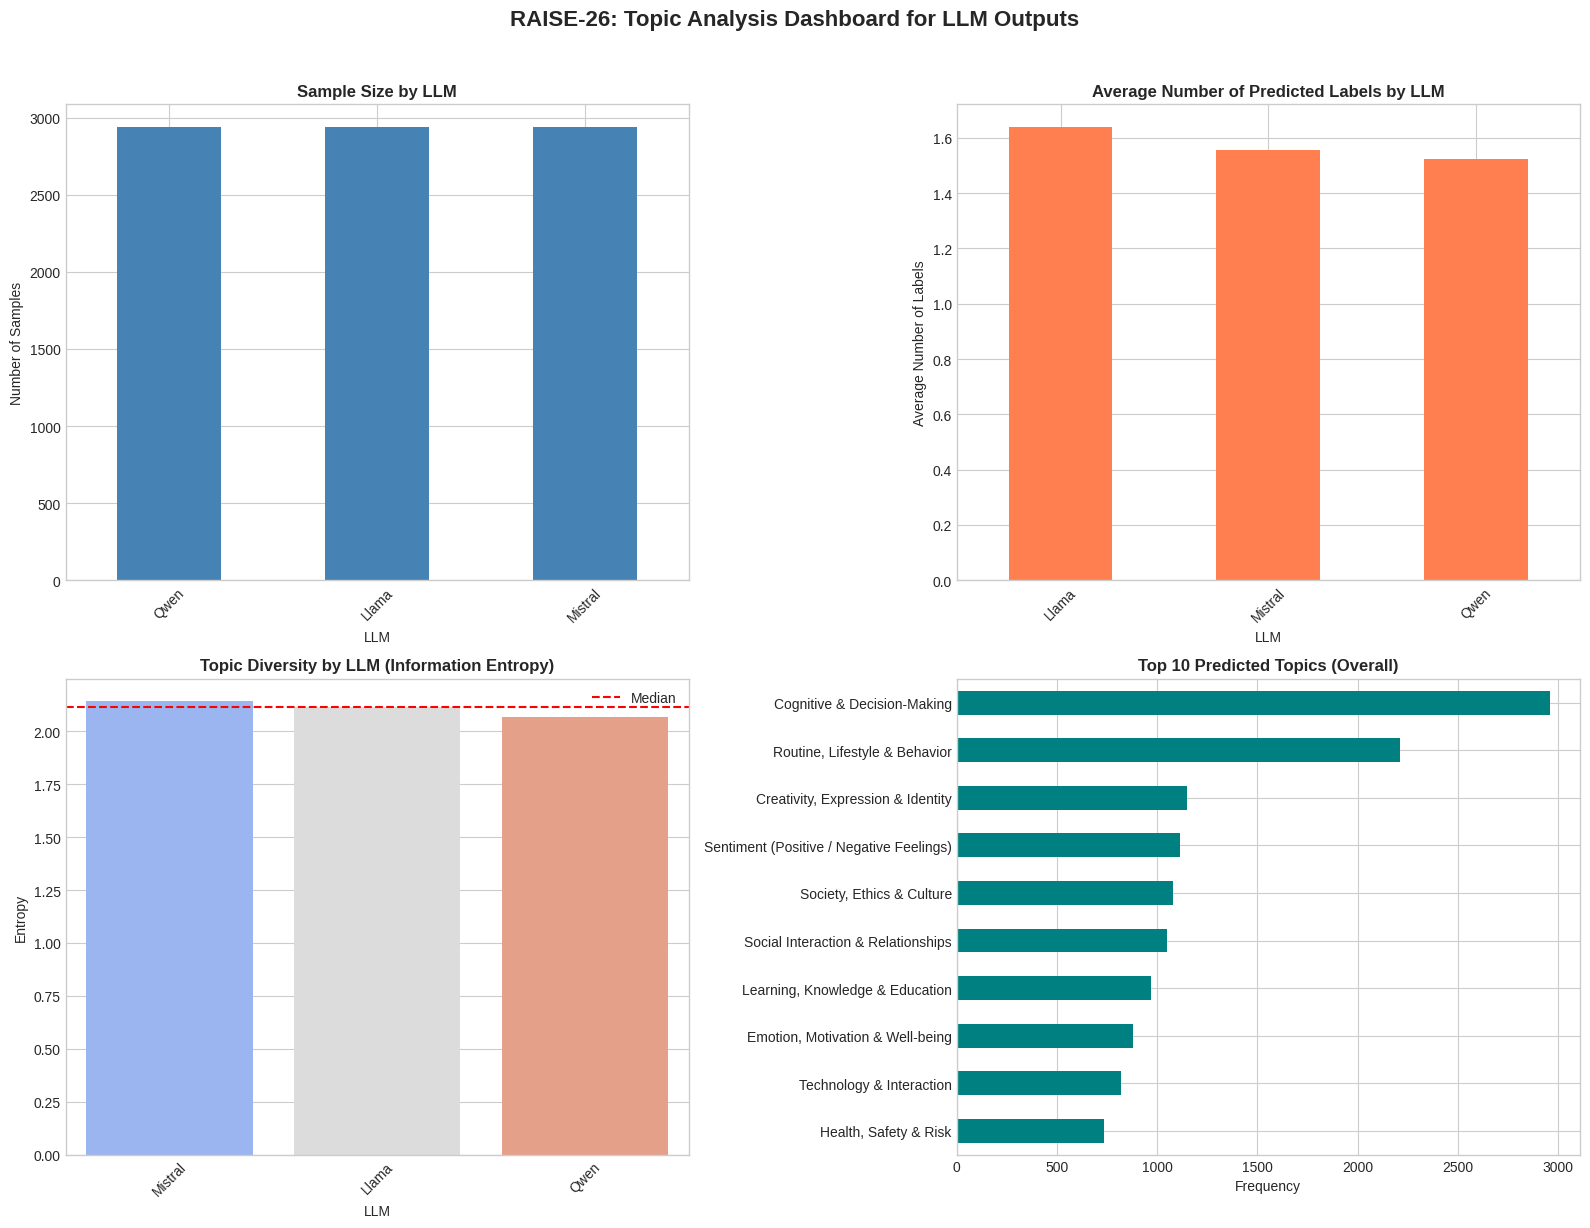

In [59]:
# ============================================================
# 10.10 Integrated Visualization Dashboard (New)
# ============================================================

if dfC is not None and 'LLM' in dfC.columns:
    print("\n" + "="*60)
    print("📊 Integrated Visualization Dashboard")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Sample size by LLM
    ax1 = axes[0, 0]
    llm_counts = dfC['LLM'].value_counts()
    llm_counts.plot(kind='bar', ax=ax1, color='steelblue')
    ax1.set_title('Sample Size by LLM', fontsize=12, fontweight='bold')
    ax1.set_xlabel('LLM')
    ax1.set_ylabel('Number of Samples')
    ax1.tick_params(axis='x', rotation=45)

    # Plot 2: Average number of predicted labels per LLM
    ax2 = axes[0, 1]
    avg_labels_per_llm = (
        dfC.groupby('LLM')['num_predicted_labels']
        .mean()
        .sort_values(ascending=False)
    )
    avg_labels_per_llm.plot(kind='bar', ax=ax2, color='coral')
    ax2.set_title('Average Number of Predicted Labels by LLM',
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('LLM')
    ax2.set_ylabel('Average Number of Labels')
    ax2.tick_params(axis='x', rotation=45)

    # Plot 3: Topic diversity comparison (Information Entropy)
    ax3 = axes[1, 0]
    ent_df = pd.DataFrame(
        list(llm_entropies.items()),
        columns=['LLM', 'Entropy']
    ).sort_values('Entropy', ascending=False)

    sns.barplot(
        data=ent_df,
        x='LLM',
        y='Entropy',
        ax=ax3,
        palette='coolwarm'
    )
    ax3.set_title('Topic Diversity by LLM (Information Entropy)',
                  fontsize=12, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    ax3.axhline(
        y=np.median(list(llm_entropies.values())),
        color='red',
        linestyle='--',
        label='Median'
    )
    ax3.legend()

    # Plot 4: Overall topic label distribution (All LLMs combined)
    ax4 = axes[1, 1]
    all_labels = [
        label
        for labels in dfC['predicted_labels']
        for label in labels
    ]
    label_dist = pd.Series(all_labels).value_counts().head(10)
    label_dist.plot(kind='barh', ax=ax4, color='teal')
    ax4.set_title('Top 10 Predicted Topics (Overall)',
                  fontsize=12, fontweight='bold')
    ax4.set_xlabel('Frequency')
    ax4.invert_yaxis()

    plt.suptitle(
        'RAISE-26: Topic Analysis Dashboard for LLM Outputs',
        fontsize=16,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()
    plt.show()


**Results & Key Insights ：**

>The integrated dashboard reveals clear and consistent differences in how LLMs frame AI’s impact on human behavior.

- First, all three models contribute a similar number of samples, ensuring that observed differences are not driven by data imbalance but by model-specific tendencies.

- Second, LLaMA produces the highest average number of predicted topics per output, indicating a stronger tendency to describe AI’s influence as multi-dimensional and overlapping. Qwen, in contrast, assigns fewer labels on average, suggesting a more focused and conservative framing, while Mistral falls between the two.

- Third, topic diversity (information entropy) is highest for Mistral, implying a broader and more evenly distributed exploration of behavioral themes. Qwen shows slightly lower entropy, indicating repeated emphasis on a smaller set of dominant narratives.

- Finally, across all models, the most prominent themes relate to cognitive and decision-making processes, daily routines and behaviors, creativity and identity, emotional sentiment, and social ethics. This pattern suggests that LLM-generated narratives consistently portray AI as shaping not only actions, but also how humans think, feel, and define themselves.

>Overall, while the models converge on similar high-level themes, they differ in emphasis and breadth, reflecting distinct narrative perspectives on AI-driven human transformation.

---
# Stage 11: Conclusions and Insights

**Objective:** To summarize the analytical results and distill the key findings.

###11.1 Summary of Key Findings

In [60]:
# ============================================================
# 11.1 Summary of Key Findings
# ============================================================

print("="*70)
print("RAISE-26 NLP Pipeline - Summary of Key Findings")
print("="*70)

print("\n📊 Data Overview:")
print(f"  • Total number of samples: {len(dfA)}")
print(f"  • Number of unique behavioral labels: {NUM_LABELS}")
print(f"  • Average number of labels per sample: {dfA['num_labels'].mean():.2f}")

print("\n🏆 Model Performance:")
print(f"  • Baseline (TF-IDF + Logistic Regression):")
print(f"    - Micro-F1: {test_metrics['micro_f1']:.4f}")
print(f"    - Macro-F1: {test_metrics['macro_f1']:.4f}")

if DO_TRAINING:
    print(f"  • DistilBERT:")
    print(f"    - Micro-F1: {bert_test_metrics['micro_f1']:.4f}")
    print(f"    - Macro-F1: {bert_test_metrics['macro_f1']:.4f}")

print("\n📈 Primary Behavioral Impact Dimensions (by frequency):")
for i, (label, count) in enumerate(label_counts_final.head(5).items()):
    print(f"  {i+1}. {label}: {count} ({count/len(dfA)*100:.1f}%)")

print("\n🔍 Topic Modeling Findings:")
print(f"  • Identified {N_TOPICS} latent topics")
print(f"  • Topic coverage includes AI applications, employment impact, education, and social ethics")

if dfC is not None and 'LLM' in dfC.columns:
    print("\n🤖 LLM Output Analysis:")
    print(f"  • Analyzed outputs from {dfC['LLM'].nunique()} different LLMs")
    print(f"  • Substantial differences observed in how LLMs frame behavioral impacts")


RAISE-26 NLP Pipeline - Summary of Key Findings

📊 Data Overview:
  • Total number of samples: 10500
  • Number of unique behavioral labels: 12
  • Average number of labels per sample: 1.54

🏆 Model Performance:
  • Baseline (TF-IDF + Logistic Regression):
    - Micro-F1: 0.9430
    - Macro-F1: 0.9331
  • DistilBERT:
    - Micro-F1: 0.9214
    - Macro-F1: 0.8862

📈 Primary Behavioral Impact Dimensions (by frequency):
  1. Work, Jobs & Economy: 2526 (24.1%)
  2. Learning, Knowledge & Education: 1946 (18.5%)
  3. Technology & Interaction: 1733 (16.5%)
  4. Society, Ethics & Culture: 1584 (15.1%)
  5. Routine, Lifestyle & Behavior: 1479 (14.1%)

🔍 Topic Modeling Findings:
  • Identified 10 latent topics
  • Topic coverage includes AI applications, employment impact, education, and social ethics

🤖 LLM Output Analysis:
  • Analyzed outputs from 3 different LLMs
  • Substantial differences observed in how LLMs frame behavioral impacts


###11.2 Save Results

In [61]:
# ============================================================
# 11.2 Save Results
# ============================================================

# Save models (if trained)
import joblib
import json  # needed if you enable json.dump below

# Save baseline model
# joblib.dump(baseline_model, 'baseline_model.joblib')
# print("✓ Baseline model saved: baseline_model.joblib")

# Save label mappings
label_mapping = {
    'label2id': label2id,
    'id2label': id2label,
    'label_names': LABEL_NAMES
}
# with open('label_mapping.json', 'w', encoding='utf-8') as f:
#     json.dump(label_mapping, f, ensure_ascii=False, indent=2)
# print("✓ Label mapping saved: label_mapping.json")

# Save evaluation results
results_summary = {
    'baseline_test_metrics': test_metrics,
    'data_stats': {
        'total_samples': len(dfA),
        'num_labels': NUM_LABELS,
        'train_size': len(train_df),
        'val_size': len(val_df),
        'test_size': len(test_df)
    }
}

if DO_TRAINING:
    results_summary['distilbert_test_metrics'] = bert_test_metrics

# with open('results_summary.json', 'w', encoding='utf-8') as f:
#     json.dump(results_summary, f, ensure_ascii=False, indent=2)
# print("✓ Results summary saved: results_summary.json")

print("\n" + "="*70)
print("Pipeline execution completed!")
print("="*70)



Pipeline execution completed!


---
## 📝 Usage Guide

### Quick Start

1. Upload the data files:
   - `dataset_A_news_full_10500.csv`
   - `Dataset_C_prompts_&_queries.csv` (optional)

2. Run all cells sequentially.

3. To speed up training:
  - Reduce NUM_EPOCHS (default: 3)
  - Reduce BATCH_SIZE (CPU recommended: 8)
  - Set DO_TRAINING = False to skip DistilBERT training

### Output Files

| File                        | Description                     |
| --------------------------- | ------------------------------- |
| `baseline_model.joblib`     | Trained baseline model          |
| `best_distilbert_model.pth` | Best DistilBERT model weights   |
| `label_mapping.json`        | Label mapping configuration     |
| `results_summary.json`      | Evaluation results summary      |
| `*.png`                     | Generated visualization figures |


### References

This pipeline integrates the following methods:
  - TF-IDF + Logistic Regression (multi-label One-vs-Rest)
  - DistilBERT pretrained language model
  - NMF topic modeling
  - Multi-label stratified sampling (iterative stratification)